# CNT-forest Einzel lens: two-step build-and-test workflow

This notebook restructures the trajectory study into a **clean two-step process**:

1. **Create a specific lens + emitter** by directly specifying the full device geometry, voltages, emitter geometry, emission-model parameters, computational domain, and electrostatic grid.
2. **Test that specific lens** by computing electron trajectories from a launch bundle whose radial extent is derived from the **current CNT-forest dimensions**.

## Why this version is safer for manual studies
- the device is built from an **explicit full parameter set**, not from partial overrides that can accidentally leave old geometry values in memory,
- the trajectory launch radius is always tied to the **active** `R_forest` and `emission_edge_exclusion`,
- the notebook reports the actual **launch extent** and simple **resolution diagnostics** before and after the solve,
- rebuilding the lens and testing the lens are now **separate actions**, so you can change the physics without silently rerunning unrelated parts.

The electrostatics notebook is still assumed to be in the same directory and is used here as the source of the solver and geometry utilities.

In [1]:

from __future__ import annotations

import io
import math
import copy
import textwrap
import contextlib
from dataclasses import dataclass
from pathlib import Path

import nbformat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.interpolate import RectBivariateSpline

plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.grid"] = True
pd.options.display.float_format = "{:.6e}".format



## 1. Load context from the electrostatics notebook

The previous notebook already contains the geometry builder, electrostatic solver, and case builder.  
Here we load only the cells needed for:
- baseline parameters,
- geometry construction,
- field solves for sweeps,
- the effective canopy-emission helper (useful for launch weighting if desired).


In [2]:

PREVIOUS_NOTEBOOK = "cnt_forest_einzel_research_grade.ipynb"
BASELINE_ARRAY_FILE = "cnt_forest_einzel_baseline_arrays.npz"

FORCE_REBUILD_BASELINE = False
REBUILD_GRID = None          # example: (181, 421) or None to use baseline grid from previous notebook

# trajectory controls
T_MAX = 5.0e-9
MAX_STEP = 5.0e-12
RTOL = 1.0e-9
ATOL = np.array([1e-12, 1e-12, 1e-3, 1e-3], dtype=float)

# launch controls
DEFAULT_LAUNCH_MODE = "uniform_radius"   # "uniform_radius" or "emission_quantiles"
DEFAULT_N_RAYS = 15
DEFAULT_INITIAL_ENERGY_EV = 0.2
DEFAULT_HALF_ANGLE_DEG = 0.0
DEFAULT_Z_OFFSET = 2.0e-6

# sweep controls
SWEEP_GRID = (121, 281)  # coarse exploratory sweep; refine promising regions afterward
V_MID_SWEEP = np.linspace(300.0, 1500.0, 5)


In [3]:

def resolve_existing_path(filename: str | Path) -> Path:
    """Resolve a file path robustly for notebook use.

    Search order:
    1. exact path as given,
    2. current working directory / filename,
    3. recursive search under the current working directory,
    4. /mnt/data / filename and recursive search under /mnt/data (useful in this ChatGPT environment).
    """
    candidate = Path(filename)
    if candidate.exists():
        return candidate.resolve()

    direct_candidates = [
        Path.cwd() / filename,
        Path("/mnt/data") / filename,
    ]
    for cand in direct_candidates:
        if cand.exists():
            return cand.resolve()

    search_roots = [Path.cwd()]
    mnt_data = Path("/mnt/data")
    if mnt_data.exists():
        search_roots.append(mnt_data)

    for root in search_roots:
        matches = list(root.rglob(str(filename)))
        if matches:
            return matches[0].resolve()

    raise FileNotFoundError(f"Could not locate {filename!s}. Place it in the same directory or update the filename.")


def load_previous_notebook_context(previous_notebook: str | Path) -> dict:
    """Load selected code cells from the electrostatics notebook into a namespace."""
    previous_notebook = resolve_existing_path(previous_notebook)

    nb = nbformat.read(previous_notebook, as_version=4)

    selectors = [
        "import time",
        "# -----------------------------\n# Voltages",
        "z1_start = d1",
        "def trapz_compat",
        "def build_axisymmetric_eps_matrix",
        "def scatter_solution_to_grid",
        "A_FN = 1.541434e-6",
        "def build_case",
    ]

    namespace: dict = {}
    with contextlib.redirect_stdout(io.StringIO()):
        for marker in selectors:
            matched = None
            for cell in nb.cells:
                if cell.cell_type == "code" and marker in cell.source:
                    matched = cell.source
                    break
            if matched is None:
                raise RuntimeError(f"Could not find the required code block containing: {marker!r}")
            exec(matched, namespace)

    required = [
        "params",
        "baseline_grid",
        "R_outer",
        "z_extra",
        "build_case",
        "build_geometry",
        "compute_forest_emission",
    ]
    missing = [name for name in required if name not in namespace]
    if missing:
        raise RuntimeError(f"Previous notebook context is missing required objects: {missing}")
    return namespace


ctx = load_previous_notebook_context(PREVIOUS_NOTEBOOK)
params_base = copy.deepcopy(ctx["params"])
baseline_grid_from_prev = tuple(ctx["baseline_grid"])
R_outer_from_prev = float(ctx["R_outer"])
z_extra_from_prev = float(ctx["z_extra"])

print("Loaded context from:", resolve_existing_path(PREVIOUS_NOTEBOOK))
print("Baseline grid from previous notebook:", baseline_grid_from_prev)
print("Baseline V_MID [V]:", params_base["V_MID"])


Loaded context from: C:\Users\surya\OneDrive\Desktop\NANOTECH\E-Beam-Website-Repository\website_code\Einzel_Study\cnt_forest_einzel_research_grade.ipynb
Baseline grid from previous notebook: (181, 421)
Baseline V_MID [V]: 10000.0



## 2. Geometry and baseline-field helpers


In [4]:

def refresh_derived_geometry_params(params: dict) -> dict:
    """Recompute dependent axial positions after any geometry change."""
    p = copy.deepcopy(params)
    p["z1_start"] = p["d1"]
    p["z1_end"] = p["z1_start"] + p["t_e"]
    p["z2_start"] = p["z1_end"] + p["d2"]
    p["z2_end"] = p["z2_start"] + p["t_e"]
    p["z3_start"] = p["z2_end"] + p["d3"]
    p["z3_end"] = p["z3_start"] + p["t_e"]
    return p


def load_or_build_baseline(
    params: dict,
    array_file: str | Path = BASELINE_ARRAY_FILE,
    force_rebuild: bool = FORCE_REBUILD_BASELINE,
    rebuild_grid=None,
):
    """Load saved baseline arrays if available; otherwise rebuild the baseline case."""
    params = refresh_derived_geometry_params(params)

    try:
        array_path = resolve_existing_path(array_file)
    except FileNotFoundError:
        array_path = Path(array_file)

    if array_path.exists() and not force_rebuild:
        arr = np.load(array_path)
        r = arr["r"]
        z = arr["z"]
        V = arr["V_direct"]
        Er = arr["Er_direct"]
        Ez = arr["Ez_direct"]
        E = arr["E_direct"]

        geom = ctx["build_geometry"](r, z, params)
        case = {
            "r": r,
            "z": z,
            "dr": float(r[1] - r[0]),
            "dz": float(z[1] - z[0]),
            "geom": geom,
            "V_direct": V,
            "Er_direct": Er,
            "Ez_direct": Ez,
            "E_direct": E,
            "R_outer": float(r[-1]),
            "z_extra": float(z[-1] - params["z3_end"]),
            "Nr": int(len(r)),
            "Nz": int(len(z)),
            "loaded_from_npz": True,
        }
        case["emission"] = ctx["compute_forest_emission"](case, params)
        return case

    grid = rebuild_grid if rebuild_grid is not None else baseline_grid_from_prev
    Nr_case, Nz_case = map(int, grid)
    case = ctx["build_case"](
        R_outer_case=R_outer_from_prev,
        z_extra_case=z_extra_from_prev,
        Nr_case=Nr_case,
        Nz_case=Nz_case,
        params=params,
        run_iterative=False,
    )
    case["loaded_from_npz"] = False
    return case



## 3. Continuous field representation and geometry predicates

For trajectory integration, the field is reconstructed from a **cubic spline of the potential** rather than by interpolating \(E_r\) and \(E_z\) independently.  
That keeps the force field numerically tied to a single scalar potential and makes energy diagnostics much cleaner.


In [5]:

E_CHARGE = 1.602176634e-19
M_E = 9.1093837015e-31
Q_OVER_M = -E_CHARGE / M_E


class MeridionalPotentialInterpolator:
    """Meridional-plane field model based on a spline of V(r,z).

    We integrate trajectories in a signed transverse coordinate x (not cylindrical r),
    but evaluate the field from the axisymmetric solution using |x|.

    Ex(x,z) = sign(x) * Er(|x|,z)
    Ez(x,z) = Ez(|x|,z)
    """

    def __init__(self, case: dict, k: int = 3):
        self.r = np.asarray(case["r"])
        self.z = np.asarray(case["z"])
        self.r_min = float(self.r[0])
        self.r_max = float(self.r[-1])
        self.z_min = float(self.z[0])
        self.z_max = float(self.z[-1])

        k_r = min(int(k), len(self.r) - 1)
        k_z = min(int(k), len(self.z) - 1)
        self.V_spline = RectBivariateSpline(
            self.r, self.z, case["V_direct"], kx=k_r, ky=k_z, s=0.0
        )

    def _clip(self, r_abs, z):
        eps_r = 1e-12 + 1e-9 * max(self.r_max - self.r_min, 1.0)
        eps_z = 1e-12 + 1e-9 * max(self.z_max - self.z_min, 1.0)
        r_abs = np.clip(r_abs, self.r_min, self.r_max - eps_r)
        z = np.clip(z, self.z_min, self.z_max - eps_z)
        return r_abs, z

    def potential(self, x, z):
        x = np.asarray(x)
        z = np.asarray(z)
        r_abs, z = self._clip(np.abs(x), z)
        return self.V_spline.ev(r_abs, z)

    def field(self, x, z):
        x = np.asarray(x)
        z = np.asarray(z)
        sign_x = np.sign(x)
        sign_x = np.where(sign_x == 0.0, 0.0, sign_x)

        r_abs, z = self._clip(np.abs(x), z)
        dVdr = self.V_spline.ev(r_abs, z, dx=1, dy=0)
        dVdz = self.V_spline.ev(r_abs, z, dx=0, dy=1)

        Ex = sign_x * (-dVdr)
        Ez = -dVdz
        return Ex, Ez


def rect_sdf(r, z, r0, r1, z0, z1):
    cx = 0.5 * (r0 + r1)
    cz = 0.5 * (z0 + z1)
    hx = 0.5 * (r1 - r0)
    hz = 0.5 * (z1 - z0)

    qx = abs(r - cx) - hx
    qz = abs(z - cz) - hz
    return math.hypot(max(qx, 0.0), max(qz, 0.0)) + min(max(qx, qz), 0.0)


def disk_sdf(r, z, rc, zc, rad):
    return math.hypot(r - rc, z - zc) - rad


def rounded_rect_sdf(r, z, r0, r1, z0, z1, rad):
    cx = 0.5 * (r0 + r1)
    cz = 0.5 * (z0 + z1)
    hx = 0.5 * (r1 - r0)
    hz = 0.5 * (z1 - z0)

    rad = max(0.0, min(rad, hx, hz))

    qx = abs(r - cx) - (hx - rad)
    qz = abs(z - cz) - (hz - rad)
    return math.hypot(max(qx, 0.0), max(qz, 0.0)) + min(max(qx, qz), 0.0) - rad


def forest_sdf(r, z, R_forest, h_forest, corner_radius):
    if corner_radius <= 0.0:
        return rect_sdf(r, z, 0.0, R_forest, 0.0, h_forest)

    corner_radius = min(corner_radius, R_forest, h_forest)
    d1 = rect_sdf(r, z, 0.0, R_forest, 0.0, max(h_forest - corner_radius, 0.0))
    d2 = rect_sdf(
        r,
        z,
        0.0,
        max(R_forest - corner_radius, 0.0),
        max(h_forest - corner_radius, 0.0),
        h_forest,
    )
    d3 = disk_sdf(
        r,
        z,
        max(R_forest - corner_radius, 0.0),
        max(h_forest - corner_radius, 0.0),
        corner_radius,
    )
    return min(d1, d2, d3)


def min_conductor_sdf(x, z, params: dict) -> float:
    """Signed distance to the nearest conductor (positive outside, negative inside)."""
    r = abs(x)
    return min(
        forest_sdf(r, z, params["R_forest"], params["h_forest"], params["forest_edge_radius"]),
        rounded_rect_sdf(
            r, z,
            params["a_inner"], params["r_stack_outer"],
            params["z1_start"], params["z1_end"],
            params["edge_radius"],
        ),
        rounded_rect_sdf(
            r, z,
            params["a_inner"], params["r_stack_outer"],
            params["z2_start"], params["z2_end"],
            params["edge_radius"],
        ),
        rounded_rect_sdf(
            r, z,
            params["a_inner"], params["r_stack_outer"],
            params["z3_start"], params["z3_end"],
            params["edge_radius"],
        ),
    )



## 4. Launch model and adaptive trajectory integration


In [6]:

@dataclass
class LaunchConfig:
    n_rays: int = DEFAULT_N_RAYS
    mode: str = DEFAULT_LAUNCH_MODE              # "uniform_radius" or "emission_quantiles"
    initial_energy_eV: float = DEFAULT_INITIAL_ENERGY_EV
    launch_half_angle_deg: float = DEFAULT_HALF_ANGLE_DEG
    z_offset: float = DEFAULT_Z_OFFSET
    symmetric: bool = True


def make_launch_bundle(case: dict, params: dict, cfg: LaunchConfig) -> pd.DataFrame:
    """Build a ray bundle from either uniform-radius or emission-weighted launch points."""
    faces = case["emission"]["faces_df"].copy()

    if cfg.mode == "uniform_radius":
        r_max = params["R_forest"] - params["emission_edge_exclusion"]
        radii = np.linspace(0.0, r_max, cfg.n_rays)
        chosen = pd.DataFrame({
            "r": radii,
            "z_above": params["h_forest"] + cfg.z_offset,
            "weight": np.ones_like(radii),
        })

    elif cfg.mode == "emission_quantiles":
        if len(faces) == 0:
            raise ValueError("No canopy faces were found for emission-weighted launching.")
        weights = faces["I_ring"].to_numpy()
        if (not np.isfinite(weights).all()) or (weights.sum() <= 0):
            weights = np.ones(len(faces), dtype=float)

        cdf = np.cumsum(weights) / np.sum(weights)
        targets = np.linspace(0.0, 1.0, cfg.n_rays)
        idx = np.searchsorted(cdf, targets, side="left")
        idx = np.clip(idx, 0, len(faces) - 1)
        chosen = faces.iloc[idx].copy().reset_index(drop=True)
        chosen["weight"] = chosen["I_ring"].to_numpy()

    else:
        raise ValueError(f"Unknown launch mode: {cfg.mode}")

    v0 = math.sqrt(2.0 * E_CHARGE * cfg.initial_energy_eV / M_E)
    theta = math.radians(cfg.launch_half_angle_deg)

    chosen["x0"] = chosen["r"].astype(float)
    chosen["z0"] = chosen["z_above"].astype(float)
    chosen["vx0"] = v0 * math.sin(theta)
    chosen["vz0"] = v0 * math.cos(theta)

    records = []
    for _, row in chosen.iterrows():
        records.append({
            "ray_id": len(records),
            "x0": float(row["x0"]),
            "z0": float(row["z0"]),
            "vx0": float(row["vx0"]),
            "vz0": float(row["vz0"]),
            "weight": float(row["weight"]),
        })
        if cfg.symmetric and row["x0"] > 0.0:
            records.append({
                "ray_id": len(records),
                "x0": -float(row["x0"]),
                "z0": float(row["z0"]),
                "vx0": -float(row["vx0"]),
                "vz0": float(row["vz0"]),
                "weight": float(row["weight"]),
            })

    return pd.DataFrame(records)


def trajectory_rhs(t, y, field_model: MeridionalPotentialInterpolator):
    x, z, vx, vz = y
    Ex, Ez = field_model.field(np.array([x]), np.array([z]))
    return np.array([vx, vz, Q_OVER_M * Ex[0], Q_OVER_M * Ez[0]], dtype=float)


def make_events(field_model: MeridionalPotentialInterpolator, params: dict):
    def hit_conductor(t, y, *args):
        return min_conductor_sdf(y[0], y[1], params)
    hit_conductor.terminal = True
    hit_conductor.direction = -1

    def radial_exit(t, y, *args):
        return field_model.r_max - abs(y[0])
    radial_exit.terminal = True
    radial_exit.direction = -1

    def top_exit(t, y, *args):
        return field_model.z_max - y[1]
    top_exit.terminal = True
    top_exit.direction = -1

    def turnaround(t, y, *args):
        return y[3]  # vz
    turnaround.terminal = True
    turnaround.direction = -1

    return [hit_conductor, radial_exit, top_exit, turnaround]


def trace_single_ray(
    ray_row,
    field_model: MeridionalPotentialInterpolator,
    params: dict,
    t_max: float = T_MAX,
    max_step: float = MAX_STEP,
    rtol: float = RTOL,
    atol=ATOL,
):
    y0 = np.array([ray_row.x0, ray_row.z0, ray_row.vx0, ray_row.vz0], dtype=float)
    solution = solve_ivp(
        trajectory_rhs,
        (0.0, t_max),
        y0,
        args=(field_model,),
        method="DOP853",
        dense_output=True,
        rtol=rtol,
        atol=atol,
        max_step=max_step,
        events=make_events(field_model, params),
    )

    stop_reason = "t_max"
    stop_names = ["hit_conductor", "radial_exit", "top_exit", "turnaround"]
    for name, ev in zip(stop_names, solution.t_events):
        if len(ev) > 0:
            stop_reason = name
            break

    return solution, stop_reason


def solution_to_frame(solution, ray_id: int, weight: float, stop_reason: str) -> pd.DataFrame:
    return pd.DataFrame({
        "ray_id": ray_id,
        "t": solution.t,
        "x": solution.y[0],
        "z": solution.y[1],
        "vx": solution.y[2],
        "vz": solution.y[3],
        "weight": weight,
        "stop_reason": stop_reason,
    })


def trace_bundle(
    bundle_df: pd.DataFrame,
    field_model: MeridionalPotentialInterpolator,
    params: dict,
    t_max: float = T_MAX,
    max_step: float = MAX_STEP,
    rtol: float = RTOL,
    atol=ATOL,
):
    summaries = []
    frames = []

    for row in bundle_df.itertuples(index=False):
        solution, stop_reason = trace_single_ray(
            row,
            field_model=field_model,
            params=params,
            t_max=t_max,
            max_step=max_step,
            rtol=rtol,
            atol=atol,
        )
        frames.append(solution_to_frame(solution, row.ray_id, row.weight, stop_reason))
        summaries.append({
            "ray_id": row.ray_id,
            "x0": row.x0,
            "z0": row.z0,
            "vx0": row.vx0,
            "vz0": row.vz0,
            "weight": row.weight,
            "stop_reason": stop_reason,
            "x_end": float(solution.y[0, -1]),
            "z_end": float(solution.y[1, -1]),
            "vx_end": float(solution.y[2, -1]),
            "vz_end": float(solution.y[3, -1]),
            "t_end": float(solution.t[-1]),
            "n_steps": int(len(solution.t)),
            "solution": solution,
        })

    return pd.DataFrame(summaries), pd.concat(frames, ignore_index=True)



## 5. Spot, crossover, magnification, and numerical diagnostics


In [7]:

def weighted_rms(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    if np.sum(w) <= 0.0:
        w = np.ones_like(x)
    return math.sqrt(np.sum(w * x * x) / np.sum(w))


def max_energy_error(solution, field_model: MeridionalPotentialInterpolator) -> float:
    x = solution.y[0]
    z = solution.y[1]
    vx = solution.y[2]
    vz = solution.y[3]

    kinetic = 0.5 * M_E * (vx * vx + vz * vz)
    potential = -E_CHARGE * field_model.potential(x, z)  # q V for an electron
    total = kinetic + potential

    scale = max(np.max(np.abs(kinetic)), np.max(np.abs(potential)), 1e-30)
    return float(np.max(np.abs(total - total[0])) / scale)


def interpolate_bundle_on_z(summary_df: pd.DataFrame, z_eval: np.ndarray) -> pd.DataFrame:
    rows = []
    ok = summary_df[summary_df["stop_reason"] == "top_exit"].copy()
    for row in ok.itertuples(index=False):
        z_path = row.solution.y[1]
        x_path = row.solution.y[0]
        vx_path = row.solution.y[2]
        vz_path = row.solution.y[3]

        rows.append(pd.DataFrame({
            "ray_id": row.ray_id,
            "z": z_eval,
            "x": np.interp(z_eval, z_path, x_path),
            "vx": np.interp(z_eval, z_path, vx_path),
            "vz": np.interp(z_eval, z_path, vz_path),
            "x0": row.x0,
            "weight": row.weight,
        }))
    return pd.concat(rows, ignore_index=True)


def beam_metrics_vs_z(bundle_on_z: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for z_value, grp in bundle_on_z.groupby("z", sort=True):
        x = grp["x"].to_numpy()
        x0 = grp["x0"].to_numpy()
        w = grp["weight"].to_numpy()

        denom = np.sum(w * x0 * x0)
        m_fit = np.nan if denom <= 0.0 else np.sum(w * x * x0) / denom

        rows.append({
            "z": z_value,
            "rms_x": weighted_rms(x, w),
            "mean_abs_x": np.sum(w * np.abs(x)) / np.sum(w),
            "max_abs_x": np.max(np.abs(x)),
            "m_fit": m_fit,
        })
    return pd.DataFrame(rows)


def in_domain_focus_metrics(summary_df: pd.DataFrame, params: dict, n_eval: int = 800):
    ok = summary_df[summary_df["stop_reason"] == "top_exit"].copy()
    if len(ok) < 3:
        return None, None, None

    z_start = max(float(params["z3_end"]), float(ok["z0"].max()))
    z_stop = float(ok["z_end"].min())
    if z_stop <= z_start:
        return None, None, None

    z_eval = np.linspace(z_start, z_stop, n_eval)
    bundle_on_z = interpolate_bundle_on_z(summary_df, z_eval)
    beam_df = beam_metrics_vs_z(bundle_on_z)

    idx = int(beam_df["rms_x"].idxmin())
    focus_row = beam_df.loc[idx].to_dict()
    focus_row["edge_limited"] = bool(idx == 0 or idx == len(beam_df) - 1)
    return focus_row, beam_df, bundle_on_z


def asymptotic_focus_metrics(summary_df: pd.DataFrame):
    ok = summary_df[summary_df["stop_reason"] == "top_exit"].copy()
    if len(ok) < 2:
        return None, None

    rows = []
    for row in ok.itertuples(index=False):
        slope = row.vx_end / row.vz_end
        if abs(slope) < 1e-16:
            continue
        z_cross = row.z_end - row.x_end / slope
        if np.isfinite(z_cross):
            rows.append({
                "ray_id": row.ray_id,
                "x0": row.x0,
                "weight": row.weight,
                "slope_exit": slope,
                "z_cross_asym": z_cross,
            })

    cross_df = pd.DataFrame(rows)
    if len(cross_df) == 0:
        return None, None

    z_focus = np.average(cross_df["z_cross_asym"], weights=cross_df["weight"])
    z_std = np.sqrt(np.average((cross_df["z_cross_asym"] - z_focus) ** 2, weights=cross_df["weight"]))

    stats = {
        "z_focus_asym": float(z_focus),
        "z_focus_asym_std": float(z_std),
        "n_asym_rays": int(len(cross_df)),
    }
    return stats, cross_df


def summarize_run(summary_df: pd.DataFrame, field_model: MeridionalPotentialInterpolator, params: dict):
    result = {
        "n_launch": int(len(summary_df)),
        "n_top_exit": int((summary_df["stop_reason"] == "top_exit").sum()),
        "n_hit_conductor": int((summary_df["stop_reason"] == "hit_conductor").sum()),
        "n_turnaround": int((summary_df["stop_reason"] == "turnaround").sum()),
        "n_radial_exit": int((summary_df["stop_reason"] == "radial_exit").sum()),
        "mean_energy_drift": float(np.mean([max_energy_error(sol, field_model) for sol in summary_df["solution"]])),
        "max_energy_drift": float(np.max([max_energy_error(sol, field_model) for sol in summary_df["solution"]])),
    }

    focus_row, beam_df, bundle_on_z = in_domain_focus_metrics(summary_df, params)
    if focus_row is not None:
        result.update({f"in_domain_{k}": v for k, v in focus_row.items()})

    asym_stats, cross_df = asymptotic_focus_metrics(summary_df)
    if asym_stats is not None:
        result.update(asym_stats)

    return result, beam_df, bundle_on_z, cross_df


def run_single_case(case: dict, params: dict, launch_cfg: LaunchConfig | None = None):
    params = refresh_derived_geometry_params(params)
    launch_cfg = LaunchConfig() if launch_cfg is None else launch_cfg

    field_model = MeridionalPotentialInterpolator(case)
    bundle_df = make_launch_bundle(case, params, launch_cfg)
    summary_df, traj_df = trace_bundle(bundle_df, field_model, params)
    summary_dict, beam_df, bundle_on_z, cross_df = summarize_run(summary_df, field_model, params)

    return {
        "case": case,
        "params": params,
        "field_model": field_model,
        "launch_cfg": launch_cfg,
        "bundle_df": bundle_df,
        "summary_df": summary_df,
        "traj_df": traj_df,
        "summary": summary_dict,
        "beam_df": beam_df,
        "bundle_on_z": bundle_on_z,
        "cross_df": cross_df,
    }


In [8]:

FIELD_RELEVANT_PARAM_KEYS = [
    "V_CNT",
    "V_MID",
    "a_inner",
    "r_stack_outer",
    "t_e",
    "edge_radius",
    "d1",
    "d2",
    "d3",
    "eps_r_oxide",
    "fill_stack_with_oxide",
    "R_forest",
    "h_forest",
    "forest_edge_radius",
]

DOMAIN_RELEVANT_KEYS = [
    "R_outer",
    "z_extra",
]

BASELINE_PARAMS_FOR_CACHE = refresh_derived_geometry_params(params_base)
BASELINE_DOMAIN_FOR_CACHE = {
    "R_outer": float(R_outer_from_prev),
    "z_extra": float(z_extra_from_prev),
}

def apply_param_overrides(params_template: dict, overrides: dict | None = None) -> dict:
    """Copy a parameter dictionary, apply user overrides, and refresh dependent geometry."""
    p = copy.deepcopy(params_template)
    overrides = {} if overrides is None else dict(overrides)

    unknown = sorted(set(overrides) - set(p))
    if unknown:
        raise KeyError(f"Unknown parameter override(s): {unknown}")

    p.update(overrides)
    return refresh_derived_geometry_params(p)


def apply_domain_overrides(overrides: dict | None = None) -> dict:
    """Return the computational domain settings after optional user overrides."""
    d = copy.deepcopy(BASELINE_DOMAIN_FOR_CACHE)
    overrides = {} if overrides is None else dict(overrides)

    unknown = sorted(set(overrides) - set(d))
    if unknown:
        raise KeyError(
            f"Unknown domain override(s): {unknown}. Allowed keys are: {sorted(d)}"
        )

    d.update(overrides)
    d["R_outer"] = float(d["R_outer"])
    d["z_extra"] = float(d["z_extra"])

    if d["R_outer"] <= 0 or d["z_extra"] <= 0:
        raise ValueError("R_outer and z_extra must both be positive.")
    return d


def make_launch_config(overrides: dict | None = None) -> LaunchConfig:
    """Create a LaunchConfig from notebook defaults plus any user overrides."""
    cfg_kwargs = {
        "n_rays": DEFAULT_N_RAYS,
        "mode": DEFAULT_LAUNCH_MODE,
        "initial_energy_eV": DEFAULT_INITIAL_ENERGY_EV,
        "launch_half_angle_deg": DEFAULT_HALF_ANGLE_DEG,
        "z_offset": DEFAULT_Z_OFFSET,
        "symmetric": True,
    }
    if overrides is not None:
        cfg_kwargs.update(overrides)
    return LaunchConfig(**cfg_kwargs)


def same_field_configuration(
    params_a: dict,
    params_b: dict,
    keys=FIELD_RELEVANT_PARAM_KEYS,
    rtol: float = 0.0,
    atol: float = 0.0,
) -> bool:
    """Return True only if two parameter dictionaries imply the same electrostatic solve."""
    for key in keys:
        a = params_a[key]
        b = params_b[key]
        if isinstance(a, (bool, np.bool_)) or isinstance(b, (bool, np.bool_)):
            if bool(a) != bool(b):
                return False
        else:
            if not np.isclose(float(a), float(b), rtol=rtol, atol=atol):
                return False
    return True


def same_domain_configuration(
    domain_a: dict,
    domain_b: dict,
    keys=DOMAIN_RELEVANT_KEYS,
    rtol: float = 0.0,
    atol: float = 0.0,
) -> bool:
    """Return True only if two domain dictionaries imply the same solve domain."""
    for key in keys:
        if not np.isclose(float(domain_a[key]), float(domain_b[key]), rtol=rtol, atol=atol):
            return False
    return True


def build_case_for_params(
    params: dict,
    rebuild_grid=None,
    allow_cached_baseline: bool = True,
    domain_overrides: dict | None = None,
):
    """
    Build an electrostatic case for arbitrary parameters.

    Important: the cached NPZ baseline is reused only when the *electrostatic*
    configuration and computational domain both match the original baseline
    exactly. Any geometry, voltage, or domain change forces a fresh solve.
    """
    p = refresh_derived_geometry_params(params)
    domain = apply_domain_overrides(domain_overrides)

    if (
        allow_cached_baseline
        and same_field_configuration(p, BASELINE_PARAMS_FOR_CACHE)
        and same_domain_configuration(domain, BASELINE_DOMAIN_FOR_CACHE)
        and rebuild_grid is None
    ):
        case = load_or_build_baseline(
            params=p,
            array_file=BASELINE_ARRAY_FILE,
            force_rebuild=FORCE_REBUILD_BASELINE,
            rebuild_grid=rebuild_grid,
        )
        case["loaded_from_npz"] = True
        return case

    grid = rebuild_grid if rebuild_grid is not None else baseline_grid_from_prev
    Nr_case, Nz_case = map(int, grid)
    case = ctx["build_case"](
        R_outer_case=domain["R_outer"],
        z_extra_case=domain["z_extra"],
        Nr_case=Nr_case,
        Nz_case=Nz_case,
        params=p,
        run_iterative=False,
    )
    case["loaded_from_npz"] = False
    return case


def manual_experiment(
    param_overrides: dict | None = None,
    launch_overrides: dict | None = None,
    domain_overrides: dict | None = None,
    rebuild_grid=None,
    allow_cached_baseline: bool = True,
):
    """
    Convenience wrapper for one-off manual tests.

    Returns
    -------
    params, case, launch_cfg, run_result, summary_table
    """
    p = apply_param_overrides(params_base, param_overrides)
    case = build_case_for_params(
        p,
        rebuild_grid=rebuild_grid,
        allow_cached_baseline=allow_cached_baseline,
        domain_overrides=domain_overrides,
    )
    launch_cfg = make_launch_config(launch_overrides)
    run_result = run_single_case(case, p, launch_cfg=launch_cfg)
    summary_table = pd.DataFrame([run_result["summary"]]).T.rename(columns={0: "value"})
    return p, case, launch_cfg, run_result, summary_table


## 6. Device-build and lens-test workflow helpers

In [9]:
EXPLICIT_PARAM_KEYS = [
    "V_CNT",
    "V_MID",
    "a_inner",
    "r_stack_outer",
    "t_e",
    "edge_radius",
    "d1",
    "d2",
    "d3",
    "eps_r_oxide",
    "fill_stack_with_oxide",
    "R_forest",
    "h_forest",
    "forest_edge_radius",
    "work_function_eV",
    "beta_forest_eff",
    "tip_areal_density",
    "tip_apex_radius",
    "emission_edge_exclusion",
]


def build_explicit_param_overrides(
    *,
    V_CNT,
    V_MID,
    a_inner,
    r_stack_outer,
    t_e,
    edge_radius,
    d1,
    d2,
    d3,
    eps_r_oxide,
    fill_stack_with_oxide,
    R_forest,
    h_forest,
    forest_edge_radius,
    work_function_eV,
    beta_forest_eff,
    tip_areal_density,
    tip_apex_radius,
    emission_edge_exclusion,
) -> dict:
    """Build a complete parameter dictionary for the active device."""
    return {
        "V_CNT": float(V_CNT),
        "V_MID": float(V_MID),
        "a_inner": float(a_inner),
        "r_stack_outer": float(r_stack_outer),
        "t_e": float(t_e),
        "edge_radius": float(edge_radius),
        "d1": float(d1),
        "d2": float(d2),
        "d3": float(d3),
        "eps_r_oxide": float(eps_r_oxide),
        "fill_stack_with_oxide": bool(fill_stack_with_oxide),
        "R_forest": float(R_forest),
        "h_forest": float(h_forest),
        "forest_edge_radius": float(forest_edge_radius),
        "work_function_eV": float(work_function_eV),
        "beta_forest_eff": float(beta_forest_eff),
        "tip_areal_density": float(tip_areal_density),
        "tip_apex_radius": float(tip_apex_radius),
        "emission_edge_exclusion": float(emission_edge_exclusion),
    }


def validate_device_inputs(params: dict, domain: dict):
    """Validate obvious physical / numerical inconsistencies before solving."""
    errors = []
    warnings = []

    positive_keys = [
        "V_CNT",
        "a_inner",
        "r_stack_outer",
        "t_e",
        "d1",
        "d2",
        "d3",
        "eps_r_oxide",
        "R_forest",
        "h_forest",
        "work_function_eV",
        "beta_forest_eff",
        "tip_areal_density",
        "tip_apex_radius",
        "R_outer",
        "z_extra",
    ]
    combined = dict(params)
    combined.update(domain)
    for key in positive_keys:
        if combined[key] <= 0.0:
            errors.append(f"{key} must be positive, got {combined[key]!r}")

    if params["r_stack_outer"] <= params["a_inner"]:
        errors.append("r_stack_outer must be larger than a_inner.")

    if params["emission_edge_exclusion"] < 0.0:
        errors.append("emission_edge_exclusion must be nonnegative.")

    active_launch_radius = params["R_forest"] - params["emission_edge_exclusion"]
    if active_launch_radius <= 0.0:
        errors.append(
            "R_forest - emission_edge_exclusion must be positive so rays can launch from the canopy."
        )

    if params["R_forest"] >= params["a_inner"]:
        warnings.append(
            "R_forest >= a_inner, so the emitter fills or overfills the aperture. Expect strong clipping or fringe-field defocusing."
        )

    if domain["R_outer"] <= params["r_stack_outer"]:
        errors.append("R_outer must be larger than r_stack_outer.")

    if domain["z_extra"] <= 0.0:
        errors.append("z_extra must be positive.")

    if params["edge_radius"] > 0.5 * min(params["t_e"], params["r_stack_outer"] - params["a_inner"]):
        warnings.append("edge_radius is large relative to the electrode thickness / wall width.")

    if params["forest_edge_radius"] > params["h_forest"]:
        warnings.append("forest_edge_radius exceeds h_forest; the canopy corner is highly rounded.")

    if domain["R_outer"] < 1.2 * params["r_stack_outer"]:
        warnings.append("R_outer is only slightly larger than the electrode stack radius; boundary effects may be stronger.")

    return errors, warnings


def device_design_table(params: dict, domain: dict, grid: tuple[int, int]) -> pd.DataFrame:
    Nr, Nz = map(int, grid)
    return pd.DataFrame(
        [
            ("V_CNT", params["V_CNT"], "V"),
            ("V_MID", params["V_MID"], "V"),
            ("a_inner", params["a_inner"] * 1e6, "µm"),
            ("r_stack_outer", params["r_stack_outer"] * 1e6, "µm"),
            ("t_e", params["t_e"] * 1e6, "µm"),
            ("d1", params["d1"] * 1e6, "µm"),
            ("d2", params["d2"] * 1e6, "µm"),
            ("d3", params["d3"] * 1e6, "µm"),
            ("R_forest", params["R_forest"] * 1e6, "µm"),
            ("h_forest", params["h_forest"] * 1e9, "nm"),
            ("emission_edge_exclusion", params["emission_edge_exclusion"] * 1e6, "µm"),
            ("active_launch_radius", (params["R_forest"] - params["emission_edge_exclusion"]) * 1e6, "µm"),
            ("R_outer", domain["R_outer"] * 1e6, "µm"),
            ("z_extra", domain["z_extra"] * 1e6, "µm"),
            ("grid_Nr", Nr, "cells"),
            ("grid_Nz", Nz, "cells"),
        ],
        columns=["quantity", "value", "unit"],
    )


def resolution_diagnostic_table(params: dict, domain: dict, grid: tuple[int, int]) -> pd.DataFrame:
    Nr, Nz = map(int, grid)
    z_max = params["z3_end"] + domain["z_extra"]

    dr = domain["R_outer"] / max(Nr - 1, 1)
    dz = z_max / max(Nz - 1, 1)

    radial_features = [
        ("a_inner", params["a_inner"], dr),
        ("wall_width", params["r_stack_outer"] - params["a_inner"], dr),
        ("R_forest", params["R_forest"], dr),
        ("active_launch_radius", params["R_forest"] - params["emission_edge_exclusion"], dr),
        ("edge_radius", params["edge_radius"], dr),
        ("forest_edge_radius", params["forest_edge_radius"], dr),
    ]
    axial_features = [
        ("t_e", params["t_e"], dz),
        ("d1", params["d1"], dz),
        ("d2", params["d2"], dz),
        ("d3", params["d3"], dz),
        ("h_forest", params["h_forest"], dz),
    ]

    rows = []
    for name, scale, spacing in radial_features + axial_features:
        if scale <= 0.0:
            cells = np.nan
            verdict = "n/a"
        else:
            cells = scale / spacing
            if cells < 2.0:
                verdict = "under-resolved"
            elif cells < 5.0:
                verdict = "coarse"
            else:
                verdict = "okay"
        rows.append(
            {
                "feature": name,
                "feature_size_m": scale,
                "grid_spacing_m": spacing,
                "cells_across_feature": cells,
                "verdict": verdict,
            }
        )

    diag = pd.DataFrame(rows)
    diag.attrs["dr"] = dr
    diag.attrs["dz"] = dz
    diag.attrs["z_max"] = z_max
    return diag


def create_lens_emitter(
    explicit_params: dict,
    *,
    domain_overrides: dict | None = None,
    rebuild_grid=None,
    allow_cached_baseline: bool = False,
):
    """
    Step 1: build one fully specified lens + emitter.

    Parameters
    ----------
    explicit_params
        Complete parameter dictionary for all lens, emitter, and emission-model values.
    domain_overrides
        Dictionary with the computational-domain keys R_outer and z_extra.
    rebuild_grid
        Electrostatic grid as (Nr, Nz).
    allow_cached_baseline
        Leave False for manual studies unless you intentionally want the exact old baseline cache.
    """
    p = apply_param_overrides(params_base, explicit_params)
    domain = apply_domain_overrides(domain_overrides)
    grid = tuple(rebuild_grid if rebuild_grid is not None else baseline_grid_from_prev)

    errors, warnings = validate_device_inputs(p, domain)
    if errors:
        raise ValueError("Invalid device specification:\n- " + "\n- ".join(errors))

    case = build_case_for_params(
        p,
        rebuild_grid=grid,
        allow_cached_baseline=allow_cached_baseline,
        domain_overrides=domain,
    )

    design_table = device_design_table(p, domain, (case["Nr"], case["Nz"]))
    resolution_table = resolution_diagnostic_table(p, domain, (case["Nr"], case["Nz"]))

    return {
        "params": p,
        "domain": domain,
        "grid": (case["Nr"], case["Nz"]),
        "case": case,
        "warnings": warnings,
        "design_table": design_table,
        "resolution_table": resolution_table,
    }


def infer_emitter_scaled_z_offset(
    params: dict,
    *,
    z_offset_m: float | None = None,
    z_offset_fraction_of_forest_height: float = 0.20,
    z_offset_floor_m: float = 2.0e-9,
) -> float:
    """Choose a launch height referenced to the current emitter dimensions."""
    if z_offset_m is not None:
        return float(z_offset_m)
    return float(max(z_offset_floor_m, z_offset_fraction_of_forest_height * params["h_forest"]))


def build_lens_test_config(
    params: dict,
    *,
    n_rays: int = DEFAULT_N_RAYS,
    mode: str = DEFAULT_LAUNCH_MODE,
    initial_energy_eV: float = DEFAULT_INITIAL_ENERGY_EV,
    launch_half_angle_deg: float = DEFAULT_HALF_ANGLE_DEG,
    symmetric: bool = True,
    z_offset_m: float | None = None,
    z_offset_fraction_of_forest_height: float = 0.20,
    z_offset_floor_m: float = 2.0e-9,
) -> LaunchConfig:
    """Step 2 helper: make a launch config tied to the active emitter."""
    z_offset = infer_emitter_scaled_z_offset(
        params,
        z_offset_m=z_offset_m,
        z_offset_fraction_of_forest_height=z_offset_fraction_of_forest_height,
        z_offset_floor_m=z_offset_floor_m,
    )
    return LaunchConfig(
        n_rays=int(n_rays),
        mode=mode,
        initial_energy_eV=float(initial_energy_eV),
        launch_half_angle_deg=float(launch_half_angle_deg),
        z_offset=float(z_offset),
        symmetric=bool(symmetric),
    )


def launch_diagnostic_table(run_result: dict) -> pd.DataFrame:
    bundle = run_result["bundle_df"].copy()
    if len(bundle) == 0:
        return pd.DataFrame(columns=["metric", "value", "unit"])

    return pd.DataFrame(
        [
            ("n_launch_points", len(bundle), "rays"),
            ("min_x0", bundle["x0"].min() * 1e6, "µm"),
            ("max_x0", bundle["x0"].max() * 1e6, "µm"),
            ("max_abs_x0", bundle["x0"].abs().max() * 1e6, "µm"),
            ("z0", bundle["z0"].iloc[0] * 1e9, "nm"),
            ("initial_energy_eV", run_result["launch_cfg"].initial_energy_eV, "eV"),
            ("launch_half_angle_deg", run_result["launch_cfg"].launch_half_angle_deg, "deg"),
        ],
        columns=["metric", "value", "unit"],
    )


def test_lens(
    device: dict,
    *,
    n_rays: int = DEFAULT_N_RAYS,
    mode: str = DEFAULT_LAUNCH_MODE,
    initial_energy_eV: float = DEFAULT_INITIAL_ENERGY_EV,
    launch_half_angle_deg: float = DEFAULT_HALF_ANGLE_DEG,
    symmetric: bool = True,
    z_offset_m: float | None = None,
    z_offset_fraction_of_forest_height: float = 0.20,
    z_offset_floor_m: float = 2.0e-9,
):
    """
    Step 2: compute trajectories for the already-built device.

    The launch radius is always derived from the active emitter:
        r_max = R_forest - emission_edge_exclusion
    """
    params = device["params"]
    launch_cfg = build_lens_test_config(
        params,
        n_rays=n_rays,
        mode=mode,
        initial_energy_eV=initial_energy_eV,
        launch_half_angle_deg=launch_half_angle_deg,
        symmetric=symmetric,
        z_offset_m=z_offset_m,
        z_offset_fraction_of_forest_height=z_offset_fraction_of_forest_height,
        z_offset_floor_m=z_offset_floor_m,
    )
    run_result = run_single_case(device["case"], params, launch_cfg=launch_cfg)
    summary_table = pd.DataFrame([run_result["summary"]]).T.rename(columns={0: "value"})
    launch_table = launch_diagnostic_table(run_result)
    return {
        "launch_cfg": launch_cfg,
        "run_result": run_result,
        "summary_table": summary_table,
        "launch_table": launch_table,
    }


## 6. Visualization helpers


In [10]:

def mirror_pcolormesh(ax, z_mm, r_mm, data, **kwargs):
    mesh1 = ax.pcolormesh(z_mm, r_mm, data, shading="auto", **kwargs)
    ax.pcolormesh(z_mm, -r_mm, data, shading="auto", **kwargs)
    return mesh1


def mirror_contour_conductors(ax, z_mm, r_mm, conductor_mask, **kwargs):
    ax.contour(z_mm, r_mm, conductor_mask, levels=[0.5], **kwargs)
    ax.contour(z_mm, -r_mm, conductor_mask, levels=[0.5], **kwargs)


def plot_trajectories_over_potential(run_result: dict, title: str = "Trajectories over electrostatic potential"):
    case = run_result["case"]
    traj_df = run_result["traj_df"]

    z_mm = case["z"] * 1e3
    r_mm = case["r"] * 1e3
    V = case["V_direct"]
    conductor_mask = (case["geom"]["conductor_id"] > 0).astype(float)

    fig, ax = plt.subplots(figsize=(9.0, 5.5))
    mesh = mirror_pcolormesh(ax, z_mm, r_mm, V, cmap="coolwarm")
    mirror_contour_conductors(ax, z_mm, r_mm, conductor_mask, colors="k", linewidths=0.8)

    for _, grp in traj_df.groupby("ray_id"):
        ax.plot(grp["z"] * 1e3, grp["x"] * 1e3, linewidth=1.2)

    ax.set_xlabel("z [mm]")
    ax.set_ylabel("signed transverse coordinate x [mm]")
    ax.set_title(title)
    fig.colorbar(mesh, ax=ax, label="V [V]")
    return fig, ax


def plot_trajectories_over_field(run_result: dict, title: str = "Trajectories over |E|"):
    case = run_result["case"]
    traj_df = run_result["traj_df"]

    z_mm = case["z"] * 1e3
    r_mm = case["r"] * 1e3
    Emag = np.asarray(case["E_direct"], dtype=float)
    Emag = np.maximum(Emag, 1e2)
    logE = np.log10(Emag)
    conductor_mask = (case["geom"]["conductor_id"] > 0).astype(float)

    fig, ax = plt.subplots(figsize=(9.0, 5.5))
    mesh = mirror_pcolormesh(ax, z_mm, r_mm, logE, cmap="inferno")
    mirror_contour_conductors(ax, z_mm, r_mm, conductor_mask, colors="cyan", linewidths=0.8)

    for _, grp in traj_df.groupby("ray_id"):
        ax.plot(grp["z"] * 1e3, grp["x"] * 1e3, linewidth=1.2, color="white", alpha=0.90)

    ax.set_xlabel("z [mm]")
    ax.set_ylabel("signed transverse coordinate x [mm]")
    ax.set_title(title)
    fig.colorbar(mesh, ax=ax, label=r"$\log_{10}|E|$ [V/m]")
    return fig, ax


def plot_beam_metrics(run_result: dict, title_prefix: str = "Beam metrics"):
    beam_df = run_result["beam_df"]
    if beam_df is None:
        raise RuntimeError("No in-domain beam metrics are available for this run.")

    fig1, ax1 = plt.subplots(figsize=(8.0, 4.5))
    ax1.plot(beam_df["z"] * 1e3, beam_df["rms_x"] * 1e6, label="RMS radius")
    ax1.plot(beam_df["z"] * 1e3, beam_df["max_abs_x"] * 1e6, label="Envelope radius")
    ax1.set_xlabel("z [mm]")
    ax1.set_ylabel("radius [µm]")
    ax1.set_title(f"{title_prefix}: spot metrics vs z")
    ax1.legend()

    fig2, ax2 = plt.subplots(figsize=(8.0, 4.5))
    ax2.plot(beam_df["z"] * 1e3, beam_df["m_fit"])
    ax2.set_xlabel("z [mm]")
    ax2.set_ylabel("fitted magnification M")
    ax2.set_title(f"{title_prefix}: fitted magnification vs z")

    return (fig1, ax1), (fig2, ax2)


def plot_sweep_results(sweep_df: pd.DataFrame, param_name: str):
    fig1, ax1 = plt.subplots(figsize=(8.0, 4.5))
    if "in_domain_rms_x" in sweep_df:
        ax1.plot(sweep_df[param_name], sweep_df["in_domain_rms_x"] * 1e6, marker="o")
        ax1.set_ylabel("minimum in-domain RMS radius [µm]")
        ax1.set_title(f"Sweep of {param_name}: minimum in-domain spot size")
    ax1.set_xlabel(param_name)

    fig2, ax2 = plt.subplots(figsize=(8.0, 4.5))
    if "z_focus_asym" in sweep_df:
        ax2.plot(sweep_df[param_name], sweep_df["z_focus_asym"] * 1e3, marker="o")
        ax2.set_ylabel("asymptotic focal / crossover z [mm]")
        ax2.set_title(f"Sweep of {param_name}: asymptotic focal plane")
    ax2.set_xlabel(param_name)

    fig3, ax3 = plt.subplots(figsize=(8.0, 4.5))
    if "in_domain_m_fit" in sweep_df:
        ax3.plot(sweep_df[param_name], sweep_df["in_domain_m_fit"], marker="o")
        ax3.set_ylabel("fitted magnification at in-domain minimum")
        ax3.set_title(f"Sweep of {param_name}: fitted magnification")
    ax3.set_xlabel(param_name)

    return (fig1, ax1), (fig2, ax2), (fig3, ax3)


In [11]:
def plot_device_preview(device: dict, title: str = "Electrostatic solution for the active device"):
    case = device["case"]
    z_mm = case["z"] * 1e3
    r_mm = case["r"] * 1e3
    V = case["V_direct"]
    conductor_mask = (case["geom"]["conductor_id"] > 0).astype(float)

    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    mesh = mirror_pcolormesh(ax, z_mm, r_mm, V, cmap="coolwarm")
    mirror_contour_conductors(ax, z_mm, r_mm, conductor_mask, colors="k", linewidths=0.8)
    ax.set_xlabel("z [mm]")
    ax.set_ylabel("signed transverse coordinate x [mm]")
    ax.set_title(title)
    fig.colorbar(mesh, ax=ax, label="V [V]")
    return fig, ax

## 7. Step 1 — create one specific lens + emitter

Edit the values in the next cell. This cell is meant to be the **single source of truth** for the active device.  
All relevant lens, emitter, emission-model, and domain parameters are entered directly here.

In [38]:
# -----------------------------
# Voltages
# -----------------------------
V_CNT = params_base["V_CNT"]     # cathode / forest conductor potential is -V_CNT [V]
V_MID = 20000     # middle lens electrode [V]

# -----------------------------
# Lens geometry
# -----------------------------
a_inner = params_base["a_inner"]             # inner aperture radius [m]
r_stack_outer = params_base["r_stack_outer"] # outer radius of the electrode + dielectric stack [m]
t_e = params_base["t_e"]                     # electrode thickness [m]
edge_radius = params_base["edge_radius"]     # rounded-corner radius [m]

d1 = params_base["d1"]  # cathode plane to electrode 1 [m]
d2 = params_base["d2"]  # electrode 1 to electrode 2 [m]
d3 = params_base["d3"]  # electrode 2 to electrode 3 [m]

# -----------------------------
# Dielectric
# -----------------------------
eps_r_oxide = params_base["eps_r_oxide"]
fill_stack_with_oxide = params_base["fill_stack_with_oxide"]

# -----------------------------
# CNT forest macro-emitter model
# -----------------------------
R_forest = 0.3e-3                    # forest radius [m]
h_forest = params_base["h_forest"]                    # forest height above cathode plane [m]
forest_edge_radius = params_base["forest_edge_radius"]  # canopy corner rounding [m]

# -----------------------------
# Effective forest-emission model
# -----------------------------
work_function_eV = params_base["work_function_eV"]
beta_forest_eff = params_base["beta_forest_eff"]
tip_areal_density = params_base["tip_areal_density"]
tip_apex_radius = params_base["tip_apex_radius"]
emission_edge_exclusion = params_base["emission_edge_exclusion"]

# -----------------------------
# Computational domain
# -----------------------------
R_outer = R_outer_from_prev   # radial truncation [m]
z_extra = z_extra_from_prev + 1e-3   # extra axial distance beyond the last electrode [m]

# -----------------------------
# Electrostatic grid
# -----------------------------
electrostatic_grid = (200, 650)  # example: (181, 421) or (250, 500)

# -----------------------------
# Build the active device
# -----------------------------
explicit_params = build_explicit_param_overrides(
    V_CNT=V_CNT,
    V_MID=V_MID,
    a_inner=a_inner,
    r_stack_outer=r_stack_outer,
    t_e=t_e,
    edge_radius=edge_radius,
    d1=d1,
    d2=d2,
    d3=d3,
    eps_r_oxide=eps_r_oxide,
    fill_stack_with_oxide=fill_stack_with_oxide,
    R_forest=R_forest,
    h_forest=h_forest,
    forest_edge_radius=forest_edge_radius,
    work_function_eV=work_function_eV,
    beta_forest_eff=beta_forest_eff,
    tip_areal_density=tip_areal_density,
    tip_apex_radius=tip_apex_radius,
    emission_edge_exclusion=emission_edge_exclusion,
)

domain_overrides = {
    "R_outer": R_outer,
    "z_extra": z_extra,
}

device = create_lens_emitter(
    explicit_params,
    domain_overrides=domain_overrides,
    rebuild_grid=electrostatic_grid,
    allow_cached_baseline=False,
)

print("Device built successfully.")
if device["warnings"]:
    print("\nWarnings:")
    for msg in device["warnings"]:
        print(" -", msg)

print("\nDesign summary:")
device["design_table"]

Device built successfully.

Design summary:


,quantity,value,unit
0,V_CNT,1.500000e+03,V
1,V_MID,2.000000e+04,V
2,a_inner,5.000000e+02,µm
3,r_stack_outer,1.100000e+03,µm
4,t_e,1.000000e+02,µm
5,d1,3.500000e+02,µm
6,d2,4.500000e+02,µm
7,d3,4.500000e+02,µm
8,R_forest,3.000000e+02,µm
9,h_forest,6.000000e+04,nm


In [39]:
print("Resolution diagnostics:")
resolution_df = device["resolution_table"].copy()
resolution_df

Resolution diagnostics:


,feature,feature_size_m,grid_spacing_m,cells_across_feature,verdict
0,a_inner,5.000000e-04,8.040201e-06,6.218750e+01,okay
1,wall_width,6.000000e-04,8.040201e-06,7.462500e+01,okay
2,R_forest,3.000000e-04,8.040201e-06,3.731250e+01,okay
3,active_launch_radius,2.750000e-04,8.040201e-06,3.420312e+01,okay
4,edge_radius,3.000000e-05,8.040201e-06,3.731250e+00,coarse
5,forest_edge_radius,2.000000e-05,8.040201e-06,2.487500e+00,coarse
6,t_e,1.000000e-04,6.086287e-06,1.643038e+01,okay
7,d1,3.500000e-04,6.086287e-06,5.750633e+01,okay
8,d2,4.500000e-04,6.086287e-06,7.393671e+01,okay
9,d3,4.500000e-04,6.086287e-06,7.393671e+01,okay


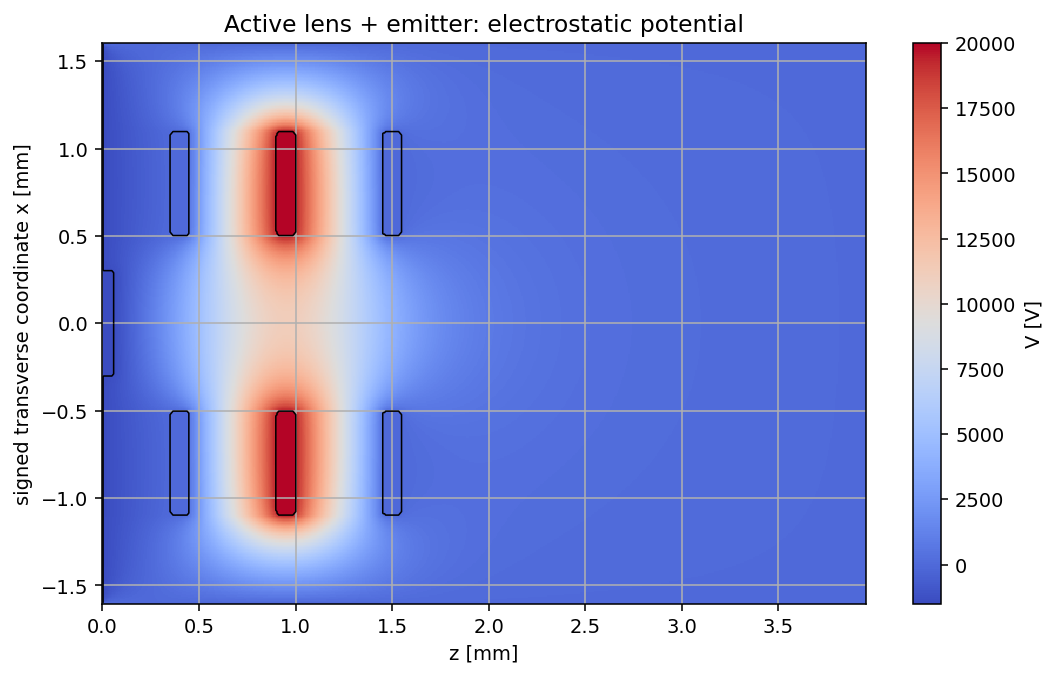

In [40]:
plot_device_preview(device, title="Active lens + emitter: electrostatic potential")
plt.show()

## 8. Step 2 — test that lens with trajectories

Edit only the launch/test settings below.  
The trajectory bundle is always constructed from the **active emitter dimensions** of the device built in Step 1.

In [52]:
# -----------------------------
# Trajectory test settings
# -----------------------------
n_rays = 15
launch_mode = "uniform_radius"   # "uniform_radius" or "emission_quantiles"
initial_energy_eV = DEFAULT_INITIAL_ENERGY_EV
launch_half_angle_deg = DEFAULT_HALF_ANGLE_DEG
symmetric = True

# Leave z_offset_m = None to scale it automatically from h_forest.
z_offset_m = None
z_offset_fraction_of_forest_height = 0.20
z_offset_floor_m = 2.0e-9

lens_test = test_lens(
    device,
    n_rays=n_rays,
    mode=launch_mode,
    initial_energy_eV=initial_energy_eV,
    launch_half_angle_deg=launch_half_angle_deg,
    symmetric=symmetric,
    z_offset_m=z_offset_m,
    z_offset_fraction_of_forest_height=z_offset_fraction_of_forest_height,
    z_offset_floor_m=z_offset_floor_m,
)

launch_cfg = lens_test["launch_cfg"]
run_result = lens_test["run_result"]
summary_table = lens_test["summary_table"]
launch_table = lens_test["launch_table"]

print("Lens test completed.")
print("\nLaunch diagnostics:")
launch_table

Lens test completed.

Launch diagnostics:


,metric,value,unit
0,n_launch_points,2.900000e+01,rays
1,min_x0,-2.750000e+02,µm
2,max_x0,2.750000e+02,µm
3,max_abs_x0,2.750000e+02,µm
4,z0,7.200000e+04,nm
5,initial_energy_eV,2.000000e-01,eV
6,launch_half_angle_deg,0.000000e+00,deg


In [53]:
summary_table

,value
n_launch,29
n_top_exit,29
n_hit_conductor,0
n_turnaround,0
n_radial_exit,0
mean_energy_drift,4.422498e-07
max_energy_drift,7.846109e-07
in_domain_z,2.913705e-03
in_domain_rms_x,1.631669e-05
in_domain_mean_abs_x,1.426756e-05


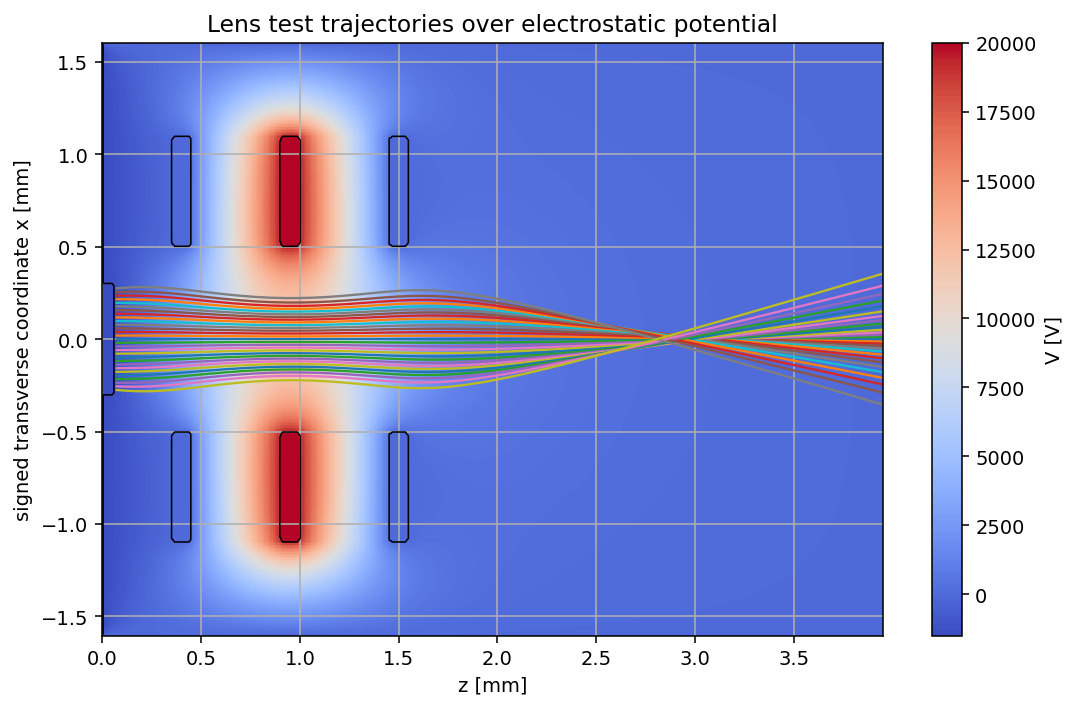

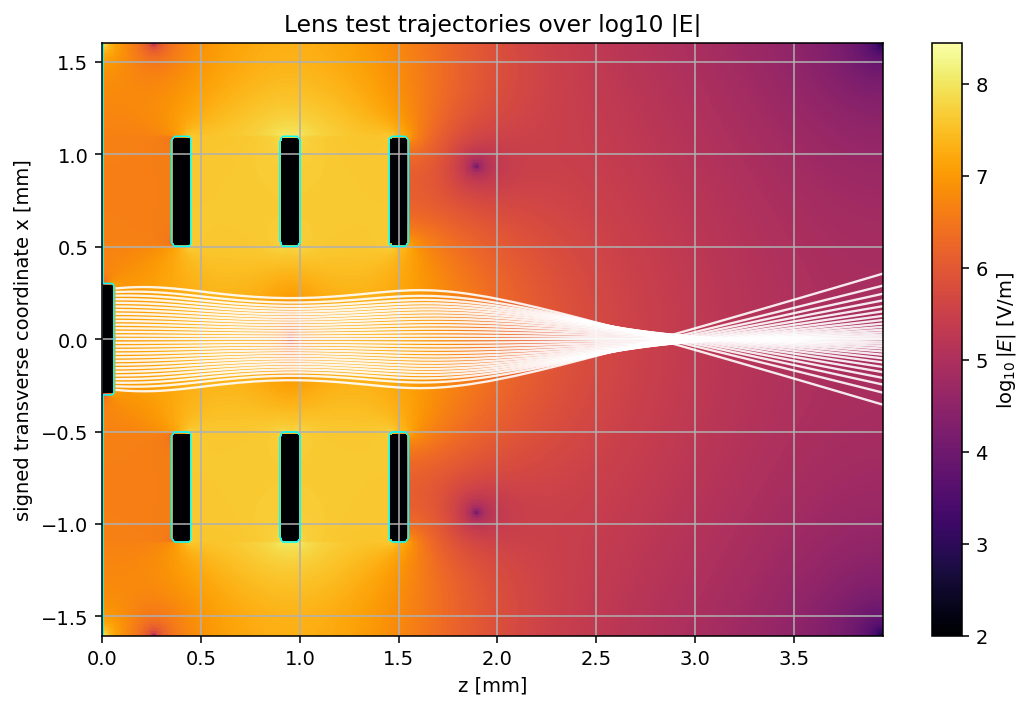

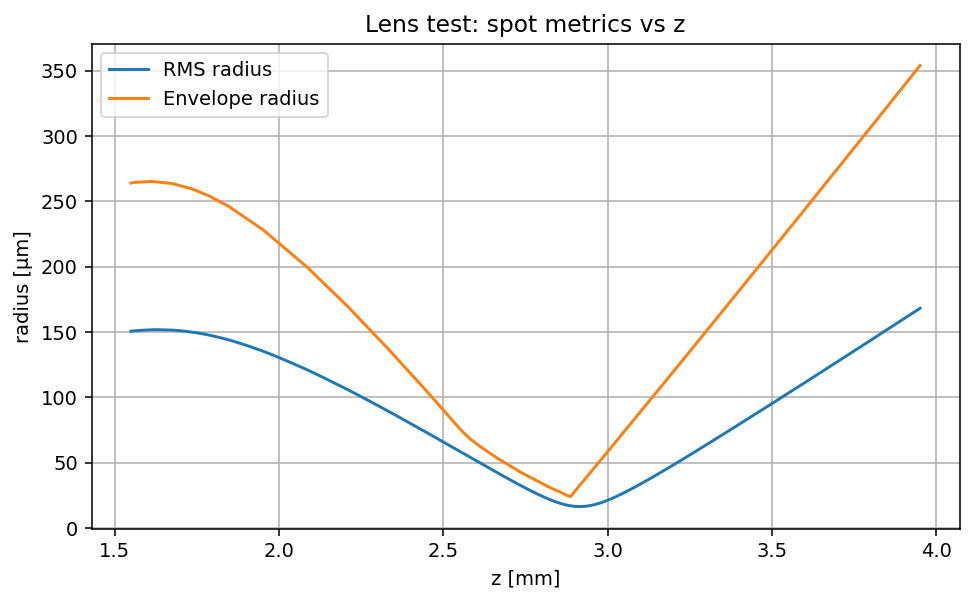

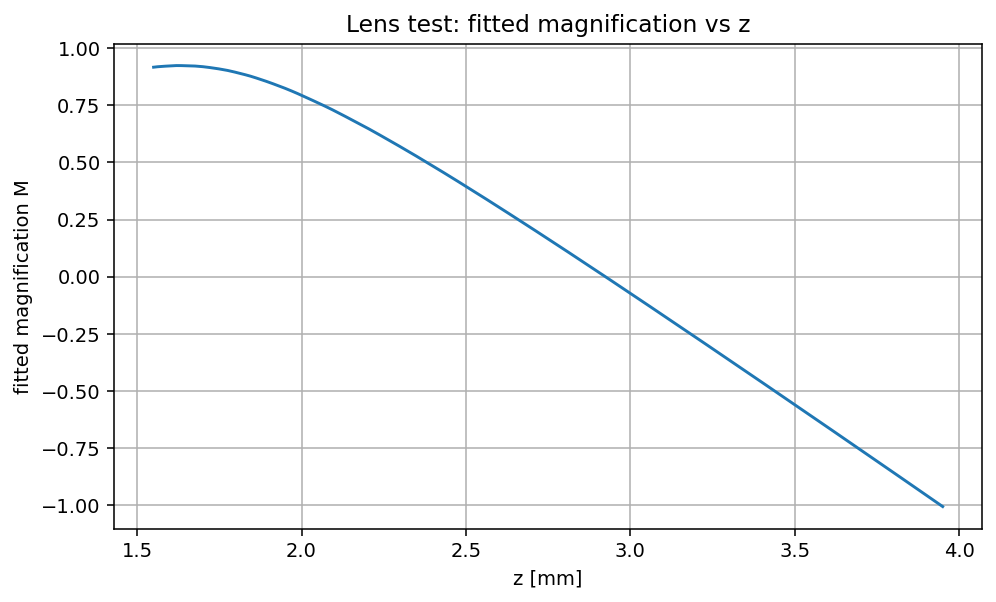

In [54]:
plot_trajectories_over_potential(
    run_result,
    title="Lens test trajectories over electrostatic potential",
)
plt.show()

plot_trajectories_over_field(
    run_result,
    title="Lens test trajectories over log10 |E|",
)
plt.savefig("figures/baseline_trajectory_bundle.pdf", bbox_inches='tight', dpi=300)
plt.show()

if run_result["beam_df"] is not None:
    plot_beam_metrics(run_result, title_prefix="Lens test")
    plt.show()

,scale,V_CNT_V,V_MID_V,initial_energy_eV,n_launch,n_top_exit,top_exit_frac,spot_rms_um,focus_z_mm,m_fit_at_spot,edge_limited,z_focus_asym_mm,z_focus_asym_std_mm,mean_abs_exit_slope,max_energy_drift
0,2.500000e-01,3.750000e+02,5.000000e+03,2.000000e-01,29,29,1.000000e+00,1.639227e+01,2.916707e+00,7.594020e-03,False,3.061589e+00,1.301344e-01,1.374223e-01,1.055163e-06
1,5.000000e-01,7.500000e+02,1.000000e+04,2.000000e-01,29,29,1.000000e+00,1.634783e+01,2.913705e+00,1.016268e-02,False,3.060989e+00,1.297639e-01,1.374888e-01,9.940024e-07
2,7.500000e-01,1.125000e+03,1.500000e+04,2.000000e-01,29,29,1.000000e+00,1.632779e+01,2.913705e+00,1.005142e-02,False,3.060757e+00,1.296090e-01,1.375157e-01,9.279638e-07
3,1.000000e+00,1.500000e+03,2.000000e+04,2.000000e-01,29,29,1.000000e+00,1.631669e+01,2.913705e+00,9.997727e-03,False,3.060630e+00,1.295160e-01,1.375304e-01,7.846109e-07
4,1.250000e+00,1.875000e+03,2.500000e+04,2.000000e-01,29,29,1.000000e+00,1.631008e+01,2.913705e+00,9.976886e-03,False,3.060548e+00,1.294548e-01,1.375401e-01,9.197802e-07
5,1.500000e+00,2.250000e+03,3.000000e+04,2.000000e-01,29,29,1.000000e+00,1.630278e+01,2.913705e+00,9.944482e-03,False,3.060488e+00,1.294092e-01,1.375473e-01,9.227133e-07
6,2.000000e+00,3.000000e+03,4.000000e+04,2.000000e-01,29,29,1.000000e+00,1.629589e+01,2.913705e+00,9.921498e-03,False,3.060409e+00,1.293469e-01,1.375569e-01,7.042155e-07


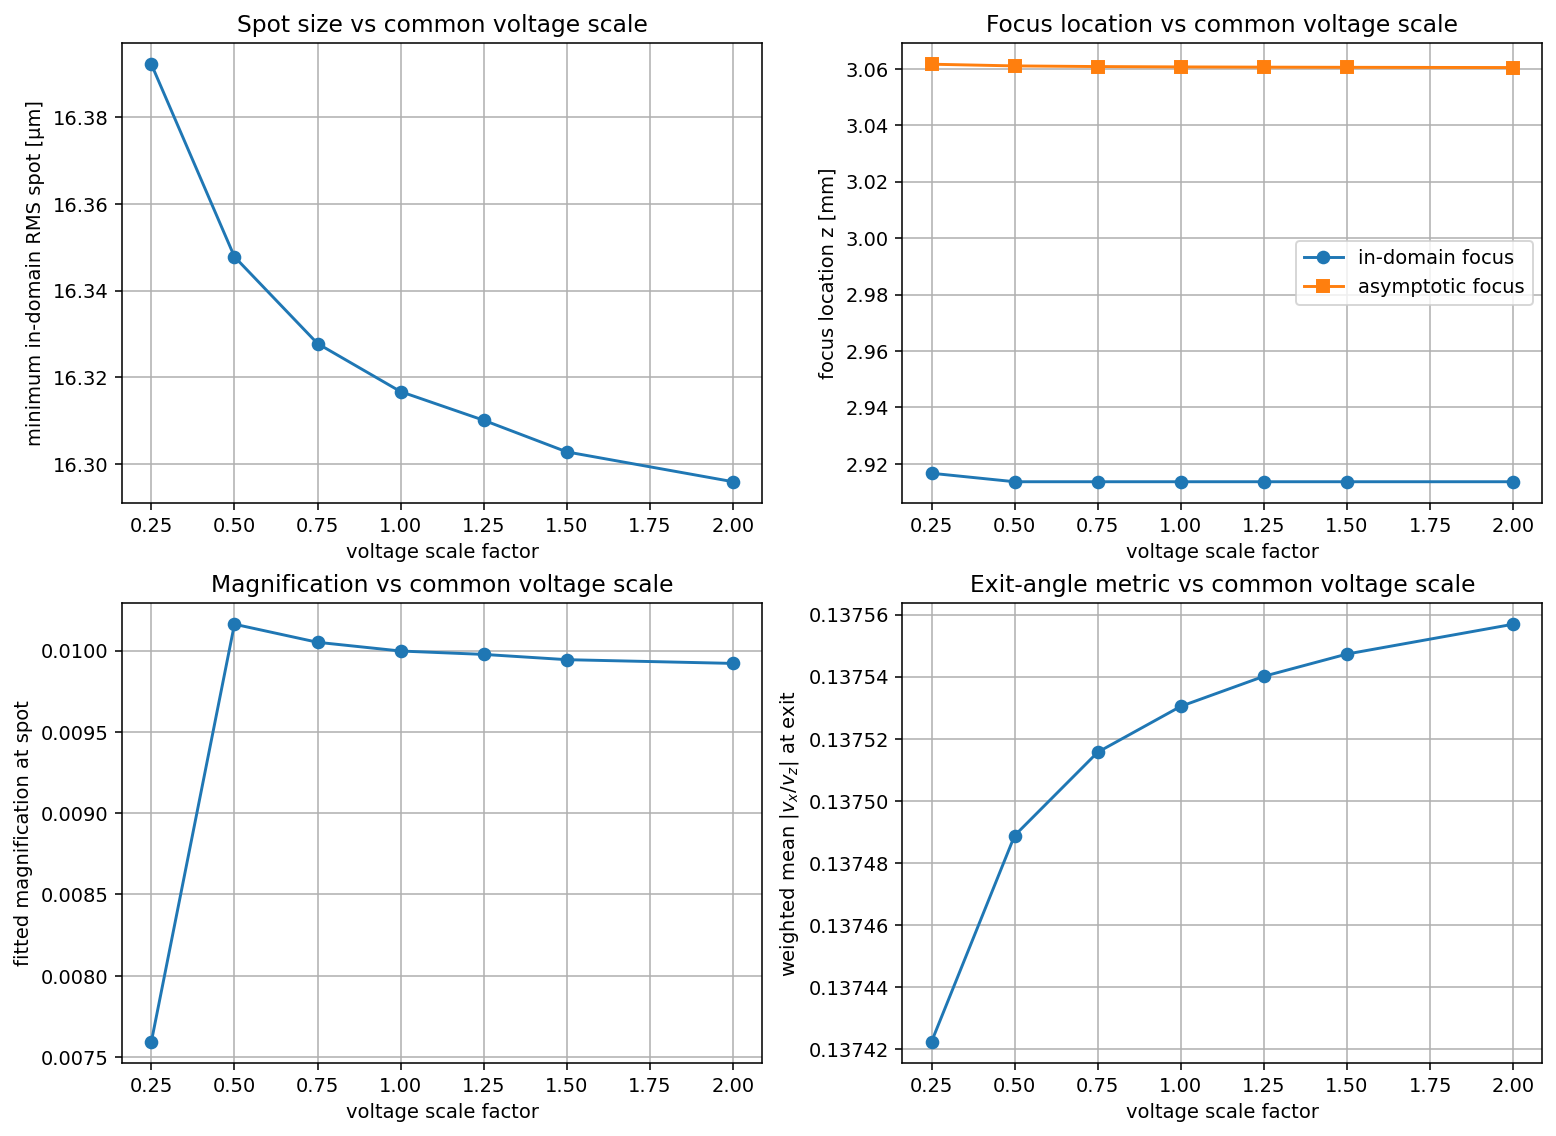

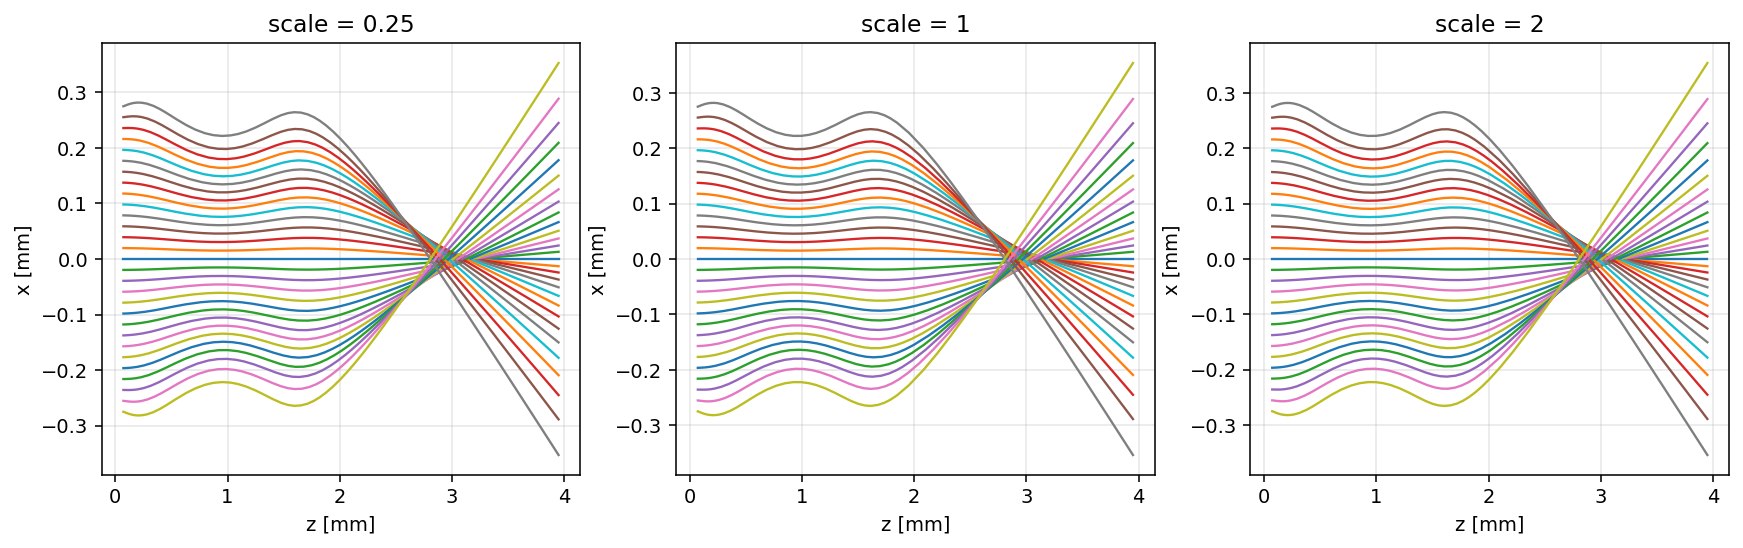

In [44]:
# Voltage-scale study: scale V_CNT and V_MID together by the same factor
# while keeping the geometry and the ratio V_MID / V_CNT fixed.

scale_factors = np.array([0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 2.00], dtype=float)

# Set this True only if you want a true similarity-style study where the launch
# kinetic energy is also scaled with the voltages. Leave False to isolate how the
# absolute electrostatic scale changes the dynamics for the same injected beam.
scale_initial_energy = False

# Reuse the active device geometry / emitter / domain / grid
base_params = {k: device["params"][k] for k in EXPLICIT_PARAM_KEYS}
base_domain = dict(device["domain"])
base_grid = tuple(device["grid"])

# Reuse the current lens-test settings if they already exist in the notebook
_current_launch_cfg = globals().get("launch_cfg", None)

base_n_rays = int(getattr(_current_launch_cfg, "n_rays", globals().get("n_rays", DEFAULT_N_RAYS)))
base_mode = str(getattr(_current_launch_cfg, "mode", globals().get("launch_mode", DEFAULT_LAUNCH_MODE)))
base_initial_energy_eV = float(
    getattr(_current_launch_cfg, "initial_energy_eV", globals().get("initial_energy_eV", DEFAULT_INITIAL_ENERGY_EV))
)
base_launch_half_angle_deg = float(
    getattr(_current_launch_cfg, "launch_half_angle_deg", globals().get("launch_half_angle_deg", DEFAULT_HALF_ANGLE_DEG))
)
base_symmetric = bool(getattr(_current_launch_cfg, "symmetric", globals().get("symmetric", True)))

base_z_offset_m = globals().get("z_offset_m", None)
base_z_offset_fraction_of_forest_height = float(globals().get("z_offset_fraction_of_forest_height", 0.20))
base_z_offset_floor_m = float(globals().get("z_offset_floor_m", 2.0e-9))

rows = []
voltage_scale_runs = {}

for s in scale_factors:
    # Copy the active device specification and scale the two electrode voltages
    p = dict(base_params)
    p["V_CNT"] = float(base_params["V_CNT"] * s)
    p["V_MID"] = float(base_params["V_MID"] * s)

    scaled_device = create_lens_emitter(
        p,
        domain_overrides=base_domain,
        rebuild_grid=base_grid,
        allow_cached_baseline=False,
    )

    this_initial_energy_eV = base_initial_energy_eV * s if scale_initial_energy else base_initial_energy_eV

    scaled_test = test_lens(
        scaled_device,
        n_rays=base_n_rays,
        mode=base_mode,
        initial_energy_eV=this_initial_energy_eV,
        launch_half_angle_deg=base_launch_half_angle_deg,
        symmetric=base_symmetric,
        z_offset_m=base_z_offset_m,
        z_offset_fraction_of_forest_height=base_z_offset_fraction_of_forest_height,
        z_offset_floor_m=base_z_offset_floor_m,
    )

    rr = scaled_test["run_result"]
    sm = rr["summary"]

    ok = rr["summary_df"][rr["summary_df"]["stop_reason"] == "top_exit"].copy()
    if len(ok) > 0:
        slopes = np.abs(ok["vx_end"].to_numpy() / ok["vz_end"].to_numpy())
        w = ok["weight"].to_numpy()
        mean_abs_exit_slope = float(np.average(slopes, weights=w))
    else:
        mean_abs_exit_slope = np.nan

    rows.append({
        "scale": float(s),
        "V_CNT_V": float(p["V_CNT"]),
        "V_MID_V": float(p["V_MID"]),
        "initial_energy_eV": float(this_initial_energy_eV),
        "n_launch": int(sm.get("n_launch", 0)),
        "n_top_exit": int(sm.get("n_top_exit", 0)),
        "top_exit_frac": float(sm.get("n_top_exit", 0)) / max(int(sm.get("n_launch", 1)), 1),
        "spot_rms_um": 1e6 * float(sm.get("in_domain_rms_x", np.nan)),
        "focus_z_mm": 1e3 * float(sm.get("in_domain_z", np.nan)),
        "m_fit_at_spot": float(sm.get("in_domain_m_fit", np.nan)),
        "edge_limited": sm.get("in_domain_edge_limited", np.nan),
        "z_focus_asym_mm": 1e3 * float(sm.get("z_focus_asym", np.nan)),
        "z_focus_asym_std_mm": 1e3 * float(sm.get("z_focus_asym_std", np.nan)),
        "mean_abs_exit_slope": mean_abs_exit_slope,
        "max_energy_drift": float(sm.get("max_energy_drift", np.nan)),
    })

    voltage_scale_runs[float(s)] = {
        "device": scaled_device,
        "test": scaled_test,
        "run_result": rr,
    }

voltage_scale_df = pd.DataFrame(rows).sort_values("scale").reset_index(drop=True)
display(voltage_scale_df)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

axes[0, 0].plot(voltage_scale_df["scale"], voltage_scale_df["spot_rms_um"], marker="o")
axes[0, 0].set_xlabel("voltage scale factor")
axes[0, 0].set_ylabel("minimum in-domain RMS spot [µm]")
axes[0, 0].set_title("Spot size vs common voltage scale")

axes[0, 1].plot(voltage_scale_df["scale"], voltage_scale_df["focus_z_mm"], marker="o", label="in-domain focus")
if np.isfinite(voltage_scale_df["z_focus_asym_mm"]).any():
    axes[0, 1].plot(voltage_scale_df["scale"], voltage_scale_df["z_focus_asym_mm"], marker="s", label="asymptotic focus")
axes[0, 1].set_xlabel("voltage scale factor")
axes[0, 1].set_ylabel("focus location z [mm]")
axes[0, 1].set_title("Focus location vs common voltage scale")
axes[0, 1].legend()

axes[1, 0].plot(voltage_scale_df["scale"], voltage_scale_df["m_fit_at_spot"], marker="o")
axes[1, 0].set_xlabel("voltage scale factor")
axes[1, 0].set_ylabel("fitted magnification at spot")
axes[1, 0].set_title("Magnification vs common voltage scale")

axes[1, 1].plot(voltage_scale_df["scale"], voltage_scale_df["mean_abs_exit_slope"], marker="o")
axes[1, 1].set_xlabel("voltage scale factor")
axes[1, 1].set_ylabel(r"weighted mean $|v_x / v_z|$ at exit")
axes[1, 1].set_title("Exit-angle metric vs common voltage scale")

plt.show()

# Optional quick trajectory comparison for a few scale factors
compare_scales = [scale_factors[0], 1.0, scale_factors[-1]]
compare_scales = [float(s) for s in compare_scales if float(s) in voltage_scale_runs]

fig, axes = plt.subplots(1, len(compare_scales), figsize=(5 * max(len(compare_scales), 1), 4), squeeze=False)
for ax, s in zip(axes[0], compare_scales):
    rr = voltage_scale_runs[s]["run_result"]
    for _, grp in rr["traj_df"].groupby("ray_id", sort=True):
        ax.plot(grp["z"] * 1e3, grp["x"] * 1e3, lw=1.2)
    ax.set_title(f"scale = {s:g}")
    ax.set_xlabel("z [mm]")
    ax.set_ylabel("x [mm]")
    ax.grid(True, alpha=0.3)

plt.show()

,sep_scale,d1_um,d2_um,d3_um,z_extra_um,a_inner_um,R_forest_um,n_launch,n_top_exit,top_exit_frac,spot_rms_um,focus_z_mm,m_fit_at_spot,edge_limited,z_focus_asym_mm,z_focus_asym_std_mm,mean_abs_exit_slope,max_energy_drift
0,1.000000e+00,3.500000e+02,4.500000e+02,4.500000e+02,2.400000e+03,5.000000e+02,3.000000e+02,29,29,1.000000e+00,1.631669e+01,2.913705e+00,9.997727e-03,False,3.060630e+00,1.295160e-01,1.375304e-01,7.846109e-07
1,1.200000e+00,4.200000e+02,5.400000e+02,5.400000e+02,2.880000e+03,5.000000e+02,3.000000e+02,29,29,1.000000e+00,4.031803e+00,2.848911e+00,7.107048e-04,False,2.904302e+00,4.133095e-02,1.327526e-01,1.022419e-06
2,1.400000e+00,4.900000e+02,6.300000e+02,6.300000e+02,3.360000e+03,5.000000e+02,3.000000e+02,29,29,1.000000e+00,4.277703e+00,2.827972e+00,-5.736582e-04,False,2.835844e+00,2.255733e-02,1.245435e-01,1.121951e-06
3,1.600000e+00,5.600000e+02,7.200000e+02,7.200000e+02,3.840000e+03,5.000000e+02,3.000000e+02,29,29,1.000000e+00,4.688495e+00,2.790213e+00,-1.052172e-03,False,2.776952e+00,2.932371e-02,1.130951e-01,1.145356e-06
4,1.800000e+00,6.300000e+02,8.100000e+02,8.100000e+02,4.320000e+03,5.000000e+02,3.000000e+02,29,29,1.000000e+00,5.473005e+00,2.820338e+00,-2.059161e-03,False,2.782243e+00,4.353704e-02,1.025307e-01,1.261648e-06
5,2.000000e+00,7.000000e+02,9.000000e+02,9.000000e+02,4.800000e+03,5.000000e+02,3.000000e+02,29,29,1.000000e+00,8.311192e+00,2.998248e+00,-3.409364e-03,False,2.926352e+00,7.108988e-02,9.761640e-02,1.021839e-06


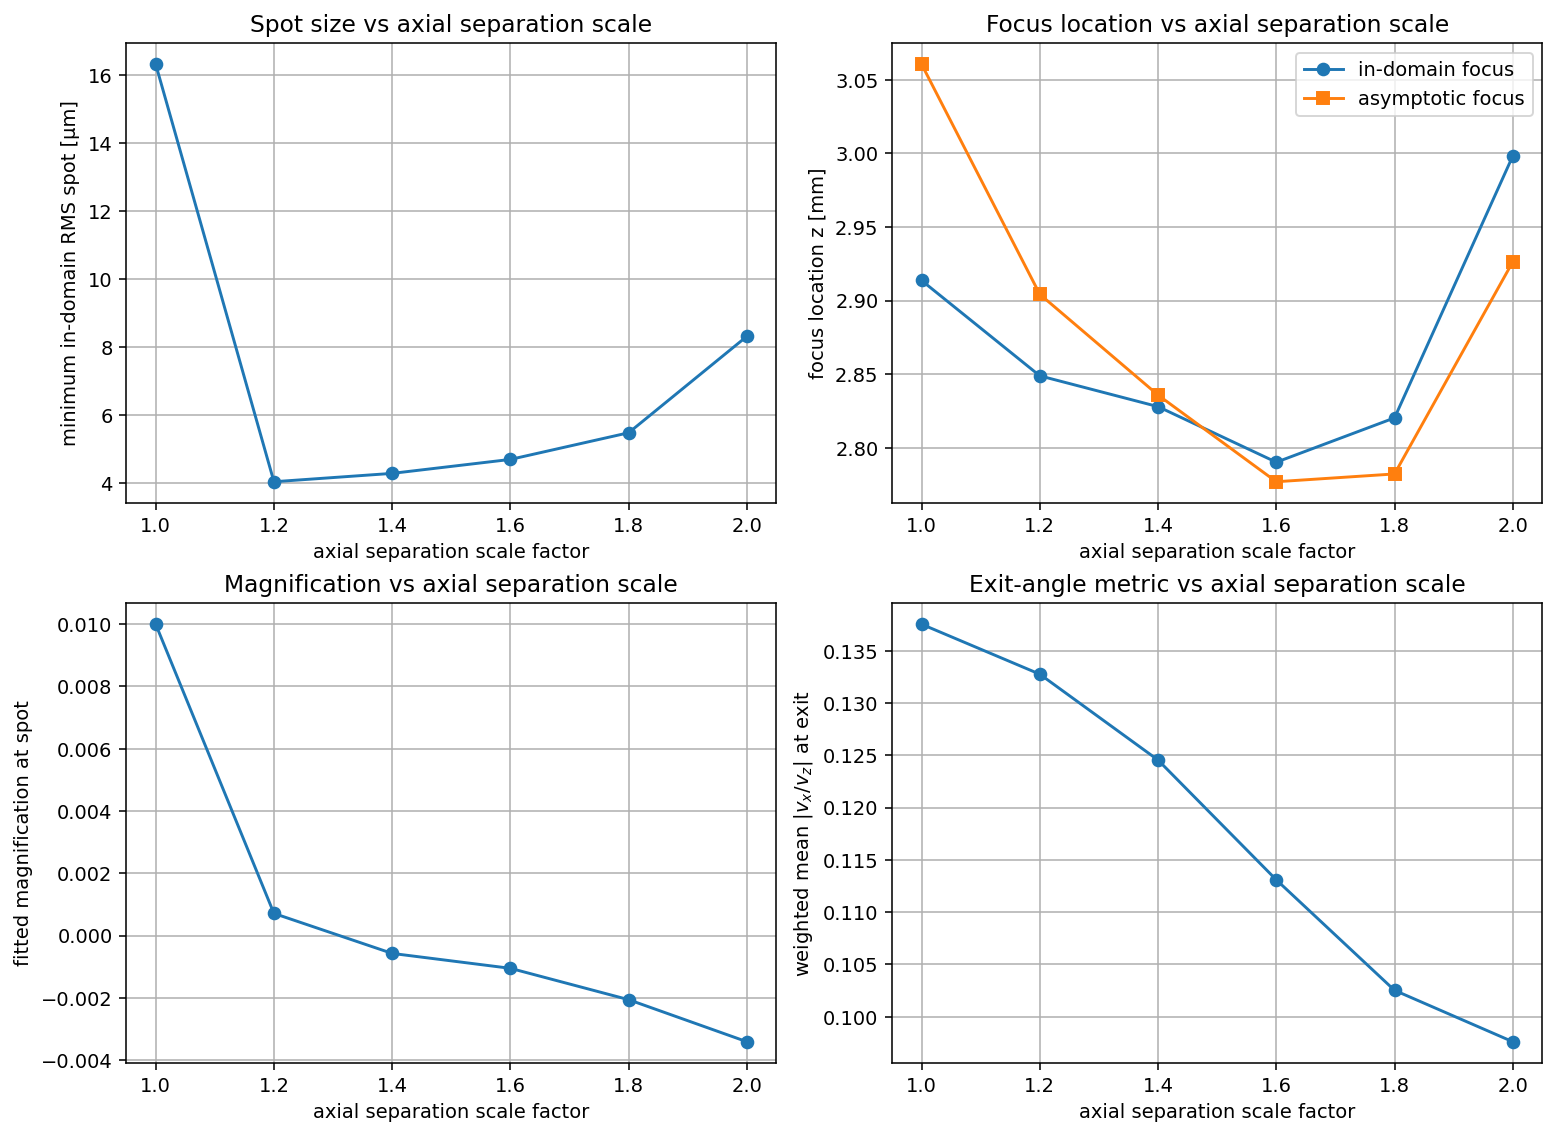

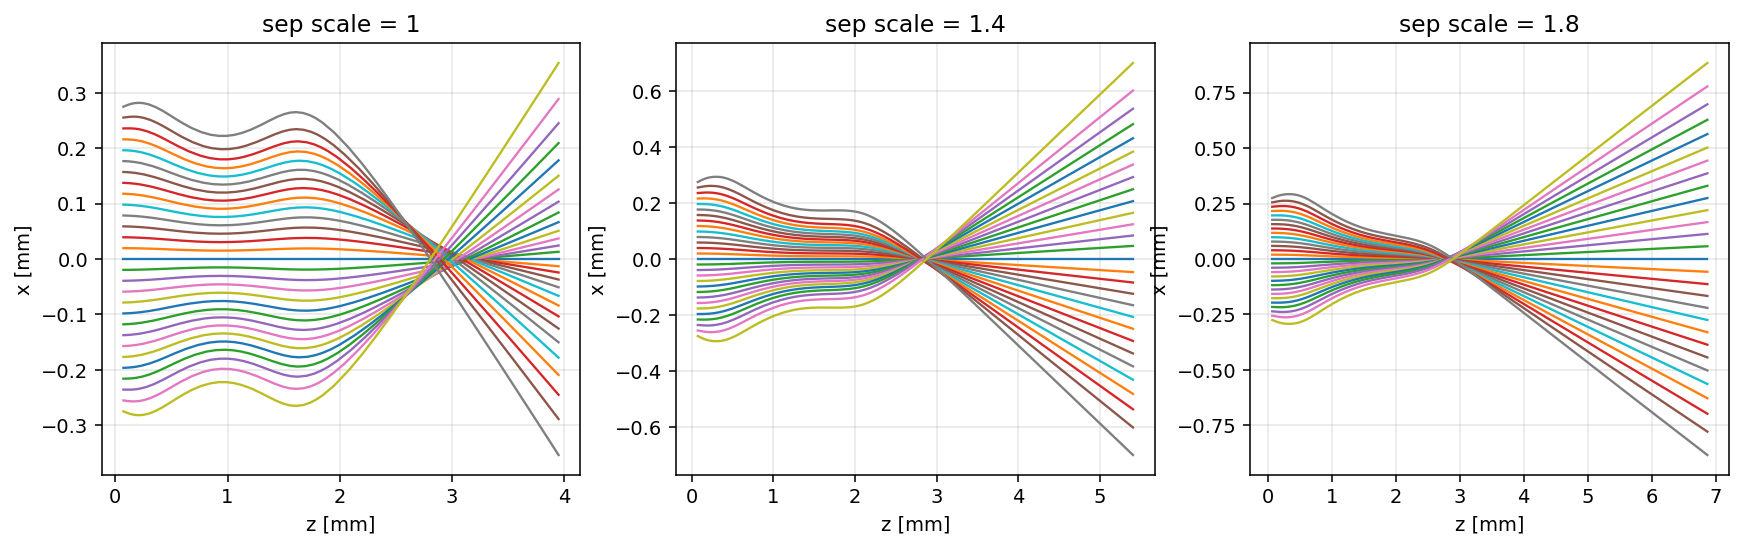

In [46]:
# Axial-separation study: scale the lens separations together
# while keeping the aperture radius and CNT forest radius fixed.

sep_scale_factors = np.array([1.00, 1.20, 1.40, 1.60, 1.80, 2.00], dtype=float)

# Reuse the active device geometry / emitter / domain / grid
base_params = {k: device["params"][k] for k in EXPLICIT_PARAM_KEYS}
base_domain = dict(device["domain"])
base_grid = tuple(device["grid"])

# Reuse the current lens-test settings if they already exist
_current_launch_cfg = globals().get("launch_cfg", None)

base_n_rays = int(getattr(_current_launch_cfg, "n_rays", globals().get("n_rays", DEFAULT_N_RAYS)))
base_mode = str(getattr(_current_launch_cfg, "mode", globals().get("launch_mode", DEFAULT_LAUNCH_MODE)))
base_initial_energy_eV = float(
    getattr(_current_launch_cfg, "initial_energy_eV", globals().get("initial_energy_eV", DEFAULT_INITIAL_ENERGY_EV))
)
base_launch_half_angle_deg = float(
    getattr(_current_launch_cfg, "launch_half_angle_deg", globals().get("launch_half_angle_deg", DEFAULT_HALF_ANGLE_DEG))
)
base_symmetric = bool(getattr(_current_launch_cfg, "symmetric", globals().get("symmetric", True)))

# If you are using an absolute launch offset, scale it with the axial geometry.
# If you are using the fraction-of-forest-height launcher, that stays unchanged.
base_z_offset_m = globals().get("z_offset_m", None)
base_z_offset_fraction_of_forest_height = float(globals().get("z_offset_fraction_of_forest_height", 0.20))
base_z_offset_floor_m = float(globals().get("z_offset_floor_m", 2.0e-9))

rows = []
axial_scale_runs = {}

for s in sep_scale_factors:
    p = dict(base_params)
    dom = dict(base_domain)

    # Scale only axial separation-like parameters
    p["d1"] = float(base_params["d1"] * s)
    p["d2"] = float(base_params["d2"] * s)
    p["d3"] = float(base_params["d3"] * s)
    dom["z_extra"] = float(base_domain["z_extra"] * s)

    # Hold aperture / emitter radii fixed explicitly
    p["a_inner"] = float(base_params["a_inner"])
    p["R_forest"] = float(base_params["R_forest"])

    scaled_device = create_lens_emitter(
        p,
        domain_overrides=dom,
        rebuild_grid=base_grid,
        allow_cached_baseline=False,
    )

    this_z_offset_m = None if base_z_offset_m is None else float(base_z_offset_m * s)

    scaled_test = test_lens(
        scaled_device,
        n_rays=base_n_rays,
        mode=base_mode,
        initial_energy_eV=base_initial_energy_eV,
        launch_half_angle_deg=base_launch_half_angle_deg,
        symmetric=base_symmetric,
        z_offset_m=this_z_offset_m,
        z_offset_fraction_of_forest_height=base_z_offset_fraction_of_forest_height,
        z_offset_floor_m=base_z_offset_floor_m,
    )

    rr = scaled_test["run_result"]
    sm = rr["summary"]

    ok = rr["summary_df"][rr["summary_df"]["stop_reason"] == "top_exit"].copy()
    if len(ok) > 0:
        slopes = np.abs(ok["vx_end"].to_numpy() / ok["vz_end"].to_numpy())
        w = ok["weight"].to_numpy()
        mean_abs_exit_slope = float(np.average(slopes, weights=w))
    else:
        mean_abs_exit_slope = np.nan

    rows.append({
        "sep_scale": float(s),
        "d1_um": 1e6 * float(p["d1"]),
        "d2_um": 1e6 * float(p["d2"]),
        "d3_um": 1e6 * float(p["d3"]),
        "z_extra_um": 1e6 * float(dom["z_extra"]),
        "a_inner_um": 1e6 * float(p["a_inner"]),
        "R_forest_um": 1e6 * float(p["R_forest"]),
        "n_launch": int(sm.get("n_launch", 0)),
        "n_top_exit": int(sm.get("n_top_exit", 0)),
        "top_exit_frac": float(sm.get("n_top_exit", 0)) / max(int(sm.get("n_launch", 1)), 1),
        "spot_rms_um": 1e6 * float(sm.get("in_domain_rms_x", np.nan)),
        "focus_z_mm": 1e3 * float(sm.get("in_domain_z", np.nan)),
        "m_fit_at_spot": float(sm.get("in_domain_m_fit", np.nan)),
        "edge_limited": sm.get("in_domain_edge_limited", np.nan),
        "z_focus_asym_mm": 1e3 * float(sm.get("z_focus_asym", np.nan)),
        "z_focus_asym_std_mm": 1e3 * float(sm.get("z_focus_asym_std", np.nan)),
        "mean_abs_exit_slope": mean_abs_exit_slope,
        "max_energy_drift": float(sm.get("max_energy_drift", np.nan)),
    })

    axial_scale_runs[float(s)] = {
        "device": scaled_device,
        "test": scaled_test,
        "run_result": rr,
    }

axial_scale_df = pd.DataFrame(rows).sort_values("sep_scale").reset_index(drop=True)
display(axial_scale_df)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

axes[0, 0].plot(axial_scale_df["sep_scale"], axial_scale_df["spot_rms_um"], marker="o")
axes[0, 0].set_xlabel("axial separation scale factor")
axes[0, 0].set_ylabel("minimum in-domain RMS spot [µm]")
axes[0, 0].set_title("Spot size vs axial separation scale")

axes[0, 1].plot(axial_scale_df["sep_scale"], axial_scale_df["focus_z_mm"], marker="o", label="in-domain focus")
if np.isfinite(axial_scale_df["z_focus_asym_mm"]).any():
    axes[0, 1].plot(axial_scale_df["sep_scale"], axial_scale_df["z_focus_asym_mm"], marker="s", label="asymptotic focus")
axes[0, 1].set_xlabel("axial separation scale factor")
axes[0, 1].set_ylabel("focus location z [mm]")
axes[0, 1].set_title("Focus location vs axial separation scale")
axes[0, 1].legend()

axes[1, 0].plot(axial_scale_df["sep_scale"], axial_scale_df["m_fit_at_spot"], marker="o")
axes[1, 0].set_xlabel("axial separation scale factor")
axes[1, 0].set_ylabel("fitted magnification at spot")
axes[1, 0].set_title("Magnification vs axial separation scale")

axes[1, 1].plot(axial_scale_df["sep_scale"], axial_scale_df["mean_abs_exit_slope"], marker="o")
axes[1, 1].set_xlabel("axial separation scale factor")
axes[1, 1].set_ylabel(r"weighted mean $|v_x / v_z|$ at exit")
axes[1, 1].set_title("Exit-angle metric vs axial separation scale")

plt.show()

# Optional quick trajectory comparison for a few separation scales
compare_sep_scales = [sep_scale_factors[0], 1.4, 1.8]
compare_sep_scales = [float(s) for s in compare_sep_scales if float(s) in axial_scale_runs]

fig, axes = plt.subplots(1, len(compare_sep_scales), figsize=(5 * max(len(compare_sep_scales), 1), 4), squeeze=False)
for ax, s in zip(axes[0], compare_sep_scales):
    rr = axial_scale_runs[s]["run_result"]
    for _, grp in rr["traj_df"].groupby("ray_id", sort=True):
        ax.plot(grp["z"] * 1e3, grp["x"] * 1e3, lw=1.2)
    ax.set_title(f"sep scale = {s:g}")
    ax.set_xlabel("z [mm]")
    ax.set_ylabel("x [mm]")
    ax.grid(True, alpha=0.3)

plt.show()

,radial_scale,axial_hold_scale,a_inner_um,r_stack_outer_um,R_forest_um,edge_radius_nm,forest_edge_radius_nm,emission_edge_exclusion_um,R_outer_um,d1_um,...,top_exit_frac,spot_rms_um,focus_z_mm,m_fit_at_spot,edge_limited,z_focus_asym_mm,z_focus_asym_std_mm,mean_abs_exit_slope,max_energy_drift,status
0,6.000000e-01,1.200000e+00,3.000000e+02,6.600000e+02,1.800000e+02,1.800000e+04,1.200000e+04,1.500000e+01,9.600000e+02,4.200000e+02,...,1.000000e+00,4.072824e+00,1.900926e+00,-4.075982e-03,False,1.858357e+00,4.096303e-02,1.037794e-01,1.182340e-06,ok
1,8.000000e-01,1.200000e+00,4.000000e+02,8.800000e+02,2.400000e+02,2.400000e+04,1.600000e+04,2.000000e+01,1.280000e+03,4.200000e+02,...,1.000000e+00,3.565158e+00,2.261377e+00,-1.301401e-03,False,2.253181e+00,2.208666e-02,1.211103e-01,9.569500e-07,ok
2,1.000000e+00,1.200000e+00,5.000000e+02,1.100000e+03,3.000000e+02,3.000000e+04,2.000000e+04,2.500000e+01,1.600000e+03,4.200000e+02,...,1.000000e+00,4.031803e+00,2.848911e+00,7.107048e-04,False,2.904302e+00,4.133095e-02,1.327526e-01,1.022419e-06,ok
3,1.200000e+00,1.200000e+00,6.000000e+02,1.320000e+03,3.600000e+02,3.600000e+04,2.400000e+04,3.000000e+01,1.920000e+03,4.200000e+02,...,1.000000e+00,2.250579e+01,3.609462e+00,1.213942e-02,False,3.819622e+00,1.912226e-01,1.294200e-01,1.124775e-06,ok
4,1.400000e+00,1.200000e+00,7.000000e+02,1.540000e+03,4.200000e+02,4.200000e+04,2.800000e+04,3.500000e+01,2.240000e+03,4.200000e+02,...,1.000000e+00,6.297668e+01,4.589887e+00,4.869248e-02,False,5.291870e+00,6.316325e-01,1.140269e-01,5.715274e-07,ok
5,1.600000e+00,1.200000e+00,8.000000e+02,1.760000e+03,4.800000e+02,4.800000e+04,3.200000e+04,4.000000e+01,2.560000e+03,4.200000e+02,...,1.000000e+00,1.980932e+02,4.680000e+00,6.682912e-01,True,8.641096e+00,2.394534e+00,8.908026e-02,8.855562e-07,ok


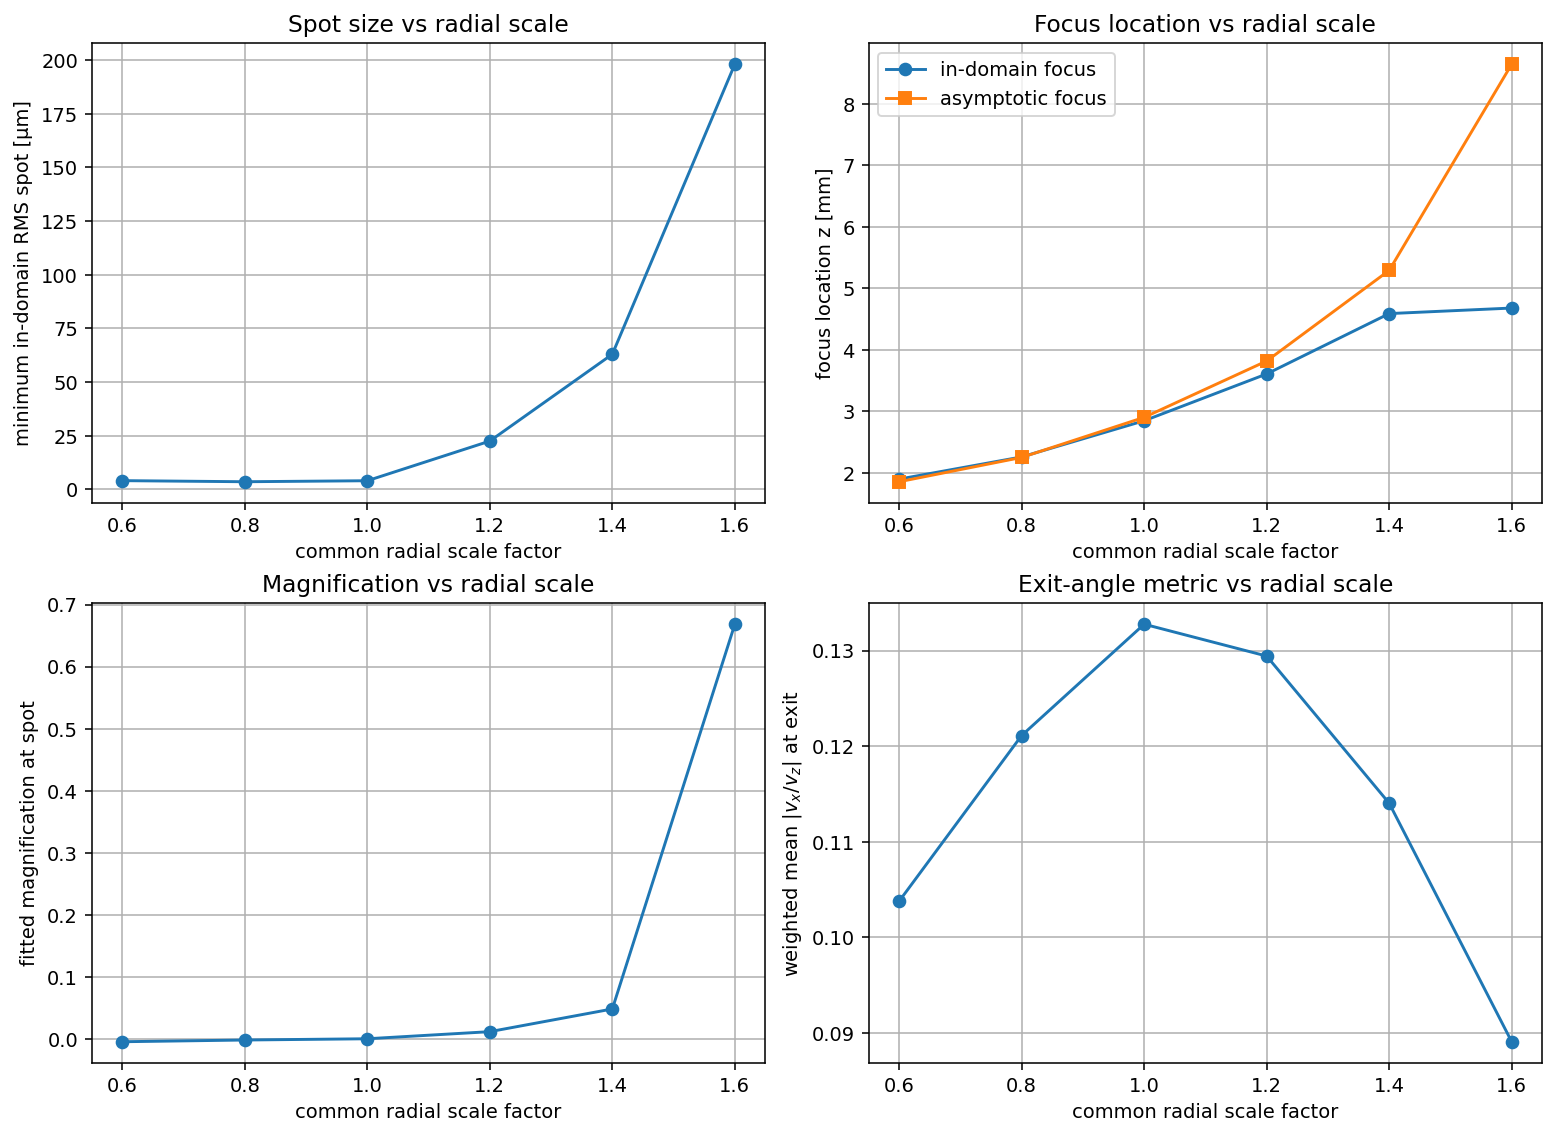

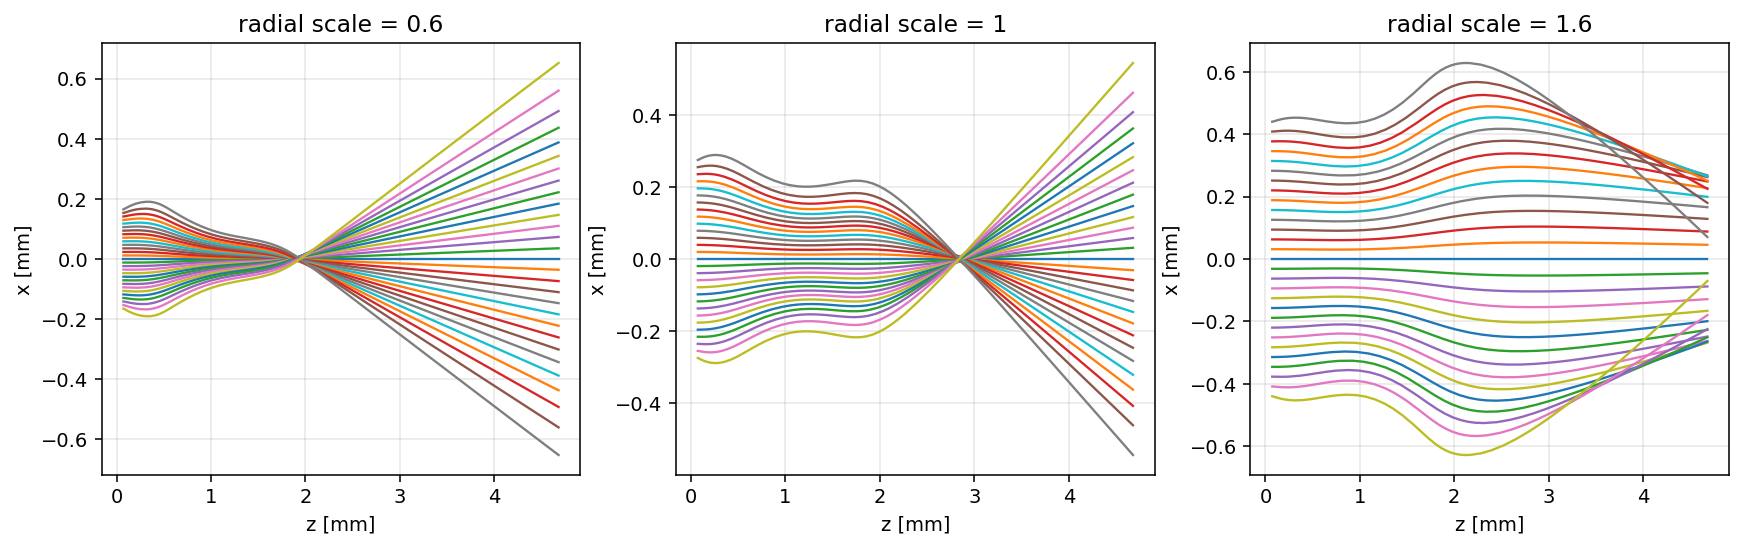

In [47]:
# Radial-geometry study:
# - Hold all axial separations at the best-performing 1.2x scale
# - Scale the radial geometry together by a common factor
# - Keep voltages and launch physics otherwise unchanged

radial_scale_factors = np.array([0.60, 0.80, 1.00, 1.20, 1.40, 1.60], dtype=float)
axial_hold_scale = 1.20

# Reuse the active device geometry / emitter / domain / grid
base_params = {k: device["params"][k] for k in EXPLICIT_PARAM_KEYS}
base_domain = dict(device["domain"])
base_grid = tuple(device["grid"])

# Reuse the current trajectory-test settings if they already exist
_current_launch_cfg = globals().get("launch_cfg", None)

base_n_rays = int(getattr(_current_launch_cfg, "n_rays", globals().get("n_rays", DEFAULT_N_RAYS)))
base_mode = str(getattr(_current_launch_cfg, "mode", globals().get("launch_mode", DEFAULT_LAUNCH_MODE)))
base_initial_energy_eV = float(
    getattr(_current_launch_cfg, "initial_energy_eV", globals().get("initial_energy_eV", DEFAULT_INITIAL_ENERGY_EV))
)
base_launch_half_angle_deg = float(
    getattr(_current_launch_cfg, "launch_half_angle_deg", globals().get("launch_half_angle_deg", DEFAULT_HALF_ANGLE_DEG))
)
base_symmetric = bool(getattr(_current_launch_cfg, "symmetric", globals().get("symmetric", True)))

# Launch offset handling: keep the current logic.
# If you are using an absolute z_offset_m, keep it fixed here because the axial geometry is fixed.
base_z_offset_m = globals().get("z_offset_m", None)
base_z_offset_fraction_of_forest_height = float(globals().get("z_offset_fraction_of_forest_height", 0.20))
base_z_offset_floor_m = float(globals().get("z_offset_floor_m", 2.0e-9))

rows = []
radial_scale_runs = {}

for s in radial_scale_factors:
    p = dict(base_params)
    dom = dict(base_domain)

    # -------------------------
    # Hold axial geometry at 1.2x
    # -------------------------
    p["d1"] = float(base_params["d1"] * axial_hold_scale)
    p["d2"] = float(base_params["d2"] * axial_hold_scale)
    p["d3"] = float(base_params["d3"] * axial_hold_scale)
    dom["z_extra"] = float(base_domain["z_extra"] * axial_hold_scale)

    # -------------------------
    # Scale radial geometry together
    # -------------------------
    radial_keys = [
        "a_inner",               # aperture radius
        "r_stack_outer",         # outer electrode / stack radius
        "R_forest",              # CNT forest radius
        "edge_radius",           # electrode corner rounding
        "forest_edge_radius",    # forest corner rounding
        "emission_edge_exclusion",
    ]
    for key in radial_keys:
        if key in p:
            p[key] = float(base_params[key] * s)

    dom["R_outer"] = float(base_domain["R_outer"] * s)

    # Basic geometric sanity checks
    note = ""
    invalid = False

    if "R_forest" in p and "emission_edge_exclusion" in p:
        if p["R_forest"] <= p["emission_edge_exclusion"]:
            invalid = True
            note = "invalid: R_forest <= emission_edge_exclusion"

    if "a_inner" in p and "r_stack_outer" in p:
        if p["a_inner"] >= p["r_stack_outer"]:
            invalid = True
            note = "invalid: a_inner >= r_stack_outer"

    if invalid:
        rows.append({
            "radial_scale": float(s),
            "axial_hold_scale": float(axial_hold_scale),
            "a_inner_um": 1e6 * float(p.get("a_inner", np.nan)),
            "r_stack_outer_um": 1e6 * float(p.get("r_stack_outer", np.nan)),
            "R_forest_um": 1e6 * float(p.get("R_forest", np.nan)),
            "edge_radius_nm": 1e9 * float(p.get("edge_radius", np.nan)),
            "forest_edge_radius_nm": 1e9 * float(p.get("forest_edge_radius", np.nan)),
            "emission_edge_exclusion_um": 1e6 * float(p.get("emission_edge_exclusion", np.nan)),
            "R_outer_um": 1e6 * float(dom.get("R_outer", np.nan)),
            "d1_um": 1e6 * float(p["d1"]),
            "d2_um": 1e6 * float(p["d2"]),
            "d3_um": 1e6 * float(p["d3"]),
            "z_extra_um": 1e6 * float(dom["z_extra"]),
            "status": note,
        })
        continue

    try:
        scaled_device = create_lens_emitter(
            p,
            domain_overrides=dom,
            rebuild_grid=base_grid,
            allow_cached_baseline=False,
        )

        scaled_test = test_lens(
            scaled_device,
            n_rays=base_n_rays,
            mode=base_mode,
            initial_energy_eV=base_initial_energy_eV,
            launch_half_angle_deg=base_launch_half_angle_deg,
            symmetric=base_symmetric,
            z_offset_m=base_z_offset_m,
            z_offset_fraction_of_forest_height=base_z_offset_fraction_of_forest_height,
            z_offset_floor_m=base_z_offset_floor_m,
        )

        rr = scaled_test["run_result"]
        sm = rr["summary"]

        ok = rr["summary_df"][rr["summary_df"]["stop_reason"] == "top_exit"].copy()
        if len(ok) > 0:
            slopes = np.abs(ok["vx_end"].to_numpy() / ok["vz_end"].to_numpy())
            w = ok["weight"].to_numpy()
            mean_abs_exit_slope = float(np.average(slopes, weights=w))
        else:
            mean_abs_exit_slope = np.nan

        launch_radius_um = np.nan
        if "bundle_df" in rr and "x0" in rr["bundle_df"].columns:
            launch_radius_um = 1e6 * float(rr["bundle_df"]["x0"].abs().max())

        rows.append({
            "radial_scale": float(s),
            "axial_hold_scale": float(axial_hold_scale),
            "a_inner_um": 1e6 * float(p.get("a_inner", np.nan)),
            "r_stack_outer_um": 1e6 * float(p.get("r_stack_outer", np.nan)),
            "R_forest_um": 1e6 * float(p.get("R_forest", np.nan)),
            "edge_radius_nm": 1e9 * float(p.get("edge_radius", np.nan)),
            "forest_edge_radius_nm": 1e9 * float(p.get("forest_edge_radius", np.nan)),
            "emission_edge_exclusion_um": 1e6 * float(p.get("emission_edge_exclusion", np.nan)),
            "R_outer_um": 1e6 * float(dom.get("R_outer", np.nan)),
            "d1_um": 1e6 * float(p["d1"]),
            "d2_um": 1e6 * float(p["d2"]),
            "d3_um": 1e6 * float(p["d3"]),
            "z_extra_um": 1e6 * float(dom["z_extra"]),
            "launch_radius_um": launch_radius_um,
            "n_launch": int(sm.get("n_launch", 0)),
            "n_top_exit": int(sm.get("n_top_exit", 0)),
            "top_exit_frac": float(sm.get("n_top_exit", 0)) / max(int(sm.get("n_launch", 1)), 1),
            "spot_rms_um": 1e6 * float(sm.get("in_domain_rms_x", np.nan)),
            "focus_z_mm": 1e3 * float(sm.get("in_domain_z", np.nan)),
            "m_fit_at_spot": float(sm.get("in_domain_m_fit", np.nan)),
            "edge_limited": sm.get("in_domain_edge_limited", np.nan),
            "z_focus_asym_mm": 1e3 * float(sm.get("z_focus_asym", np.nan)),
            "z_focus_asym_std_mm": 1e3 * float(sm.get("z_focus_asym_std", np.nan)),
            "mean_abs_exit_slope": mean_abs_exit_slope,
            "max_energy_drift": float(sm.get("max_energy_drift", np.nan)),
            "status": "ok",
        })

        radial_scale_runs[float(s)] = {
            "device": scaled_device,
            "test": scaled_test,
            "run_result": rr,
        }

    except Exception as e:
        rows.append({
            "radial_scale": float(s),
            "axial_hold_scale": float(axial_hold_scale),
            "a_inner_um": 1e6 * float(p.get("a_inner", np.nan)),
            "r_stack_outer_um": 1e6 * float(p.get("r_stack_outer", np.nan)),
            "R_forest_um": 1e6 * float(p.get("R_forest", np.nan)),
            "edge_radius_nm": 1e9 * float(p.get("edge_radius", np.nan)),
            "forest_edge_radius_nm": 1e9 * float(p.get("forest_edge_radius", np.nan)),
            "emission_edge_exclusion_um": 1e6 * float(p.get("emission_edge_exclusion", np.nan)),
            "R_outer_um": 1e6 * float(dom.get("R_outer", np.nan)),
            "d1_um": 1e6 * float(p["d1"]),
            "d2_um": 1e6 * float(p["d2"]),
            "d3_um": 1e6 * float(p["d3"]),
            "z_extra_um": 1e6 * float(dom["z_extra"]),
            "status": f"error: {type(e).__name__}: {e}",
        })

radial_scale_df = pd.DataFrame(rows).sort_values("radial_scale").reset_index(drop=True)
display(radial_scale_df)

ok_df = radial_scale_df[radial_scale_df["status"] == "ok"].copy()

if len(ok_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

    axes[0, 0].plot(ok_df["radial_scale"], ok_df["spot_rms_um"], marker="o")
    axes[0, 0].set_xlabel("common radial scale factor")
    axes[0, 0].set_ylabel("minimum in-domain RMS spot [µm]")
    axes[0, 0].set_title("Spot size vs radial scale")

    axes[0, 1].plot(ok_df["radial_scale"], ok_df["focus_z_mm"], marker="o", label="in-domain focus")
    if np.isfinite(ok_df["z_focus_asym_mm"]).any():
        axes[0, 1].plot(ok_df["radial_scale"], ok_df["z_focus_asym_mm"], marker="s", label="asymptotic focus")
    axes[0, 1].set_xlabel("common radial scale factor")
    axes[0, 1].set_ylabel("focus location z [mm]")
    axes[0, 1].set_title("Focus location vs radial scale")
    axes[0, 1].legend()

    axes[1, 0].plot(ok_df["radial_scale"], ok_df["m_fit_at_spot"], marker="o")
    axes[1, 0].set_xlabel("common radial scale factor")
    axes[1, 0].set_ylabel("fitted magnification at spot")
    axes[1, 0].set_title("Magnification vs radial scale")

    axes[1, 1].plot(ok_df["radial_scale"], ok_df["mean_abs_exit_slope"], marker="o")
    axes[1, 1].set_xlabel("common radial scale factor")
    axes[1, 1].set_ylabel(r"weighted mean $|v_x / v_z|$ at exit")
    axes[1, 1].set_title("Exit-angle metric vs radial scale")

    plt.show()

    # Optional quick trajectory comparison
    candidate_scales = [radial_scale_factors[0], 1.0, radial_scale_factors[-1]]
    compare_radial_scales = [float(s) for s in candidate_scales if float(s) in radial_scale_runs]

    fig, axes = plt.subplots(1, len(compare_radial_scales), figsize=(5 * max(len(compare_radial_scales), 1), 4), squeeze=False)
    for ax, s in zip(axes[0], compare_radial_scales):
        rr = radial_scale_runs[s]["run_result"]
        for _, grp in rr["traj_df"].groupby("ray_id", sort=True):
            ax.plot(grp["z"] * 1e3, grp["x"] * 1e3, lw=1.2)
        ax.set_title(f"radial scale = {s:g}")
        ax.set_xlabel("z [mm]")
        ax.set_ylabel("x [mm]")
        ax.grid(True, alpha=0.3)

    plt.show()

,Vmid_over_Vcnt,V_CNT_V,V_MID_V,spot_rms_um,focus_z_mm,m_fit_at_spot,z_focus_asym_mm,mean_abs_exit_slope,top_exit_frac,max_energy_drift
0,2.500000e-01,1.500000e+03,3.750000e+02,2.922088e+02,1.800000e+00,2.241586e+00,-8.026578e-01,9.715238e-02,7.931034e-01,6.572804e-07
1,5.000000e-01,1.500000e+03,7.500000e+02,2.807049e+02,1.800000e+00,2.153303e+00,-9.708684e-01,8.803973e-02,7.931034e-01,5.754247e-07
2,7.500000e-01,1.500000e+03,1.125000e+03,2.693944e+02,1.800000e+00,2.066546e+00,-1.197774e+00,7.842172e-02,7.931034e-01,9.559404e-07
3,1.000000e+00,1.500000e+03,1.500000e+03,2.585876e+02,1.800000e+00,1.983669e+00,-1.490789e+00,6.885516e-02,7.931034e-01,7.360141e-07
4,1.250000e+00,1.500000e+03,1.875000e+03,2.751188e+02,1.800000e+00,1.940506e+00,-1.892171e+00,6.487885e-02,8.620690e-01,9.298123e-07
5,1.500000e+00,1.500000e+03,2.250000e+03,2.644913e+02,1.800000e+00,1.865608e+00,-2.393970e+00,5.503991e-02,8.620690e-01,1.004712e-06
6,2.000000e+00,1.500000e+03,3.000000e+03,2.720862e+02,1.800000e+00,1.775125e+00,-4.225855e+00,3.866028e-02,9.310345e-01,1.059433e-06
7,3.000000e+00,1.500000e+03,4.500000e+03,2.371352e+02,1.800000e+00,1.547408e+00,-2.057307e+01,7.358668e-03,9.310345e-01,8.765698e-07


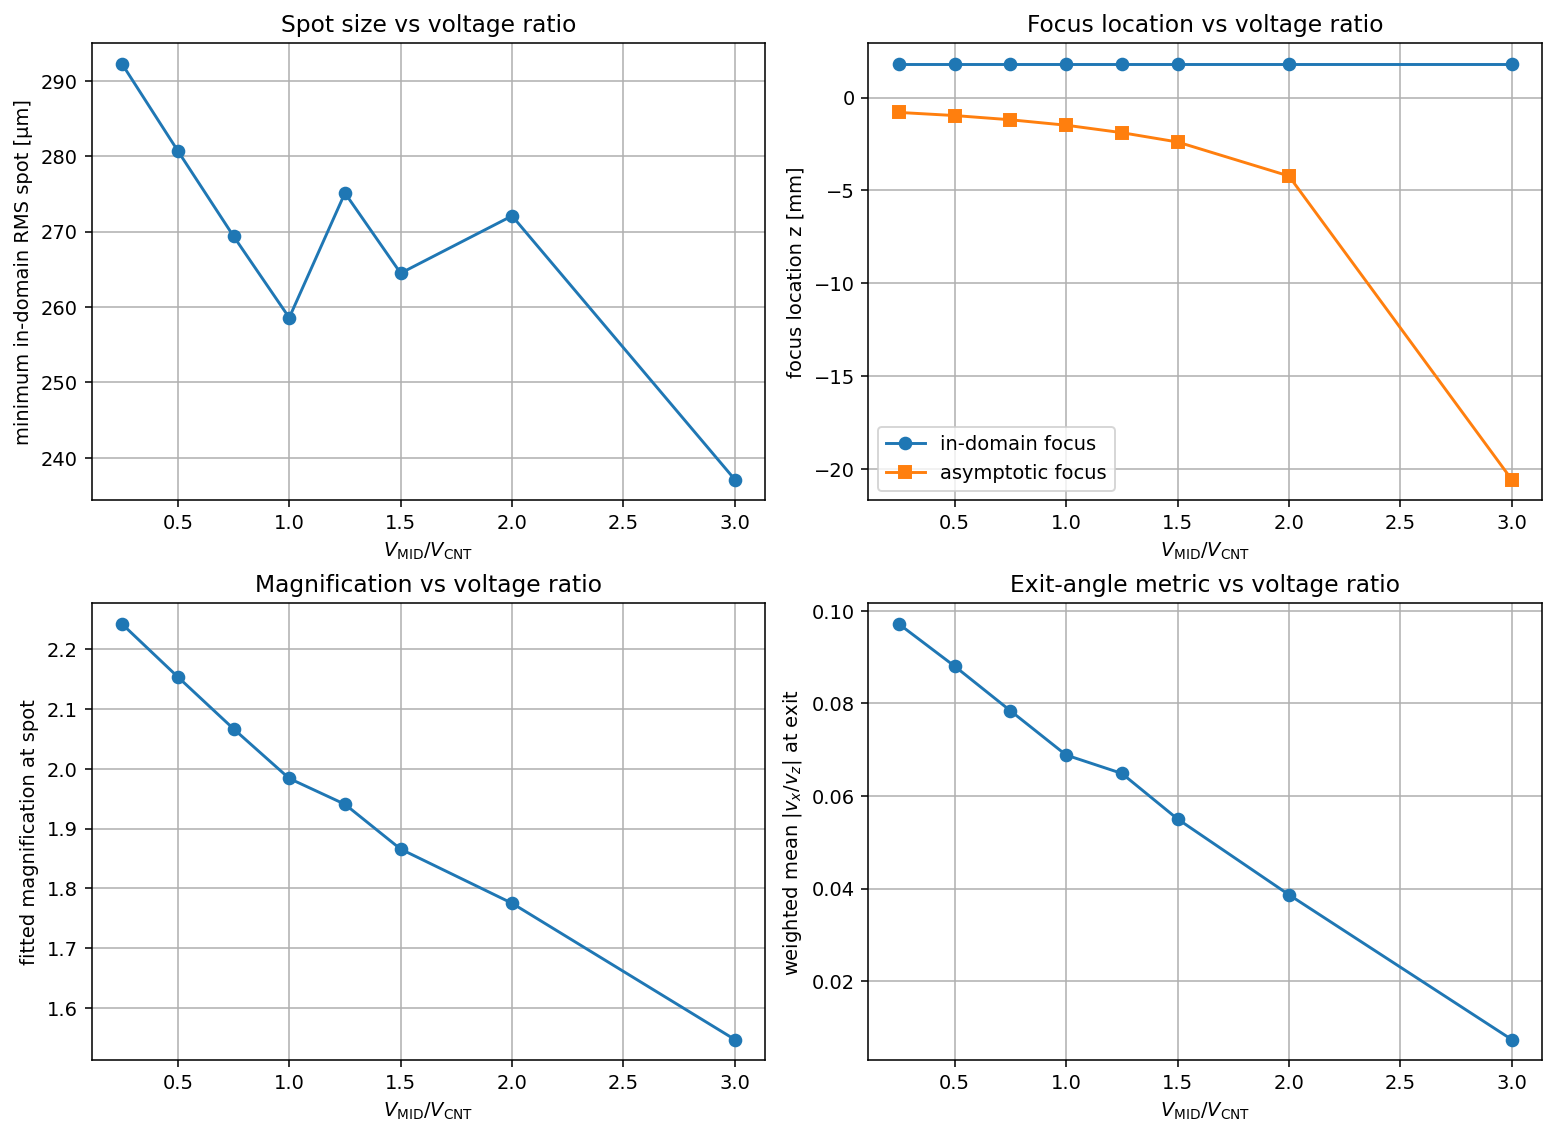

In [48]:
# Study 1: voltage-ratio sweep at fixed 1.2 axial geometry
# V_CNT is held fixed; V_MID is varied through the ratio V_MID / V_CNT.

ratio_values = np.array([0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 2.00, 3.00], dtype=float)
axial_hold_scale = 1.20

base_params = {k: device["params"][k] for k in EXPLICIT_PARAM_KEYS}
base_domain = dict(device["domain"])
base_grid = tuple(device["grid"])

_current_launch_cfg = globals().get("launch_cfg", None)
base_n_rays = int(getattr(_current_launch_cfg, "n_rays", globals().get("n_rays", DEFAULT_N_RAYS)))
base_mode = str(getattr(_current_launch_cfg, "mode", globals().get("launch_mode", DEFAULT_LAUNCH_MODE)))
base_initial_energy_eV = float(getattr(_current_launch_cfg, "initial_energy_eV", globals().get("initial_energy_eV", DEFAULT_INITIAL_ENERGY_EV)))
base_launch_half_angle_deg = float(getattr(_current_launch_cfg, "launch_half_angle_deg", globals().get("launch_half_angle_deg", DEFAULT_HALF_ANGLE_DEG)))
base_symmetric = bool(getattr(_current_launch_cfg, "symmetric", globals().get("symmetric", True)))
base_z_offset_m = globals().get("z_offset_m", None)
base_z_offset_fraction_of_forest_height = float(globals().get("z_offset_fraction_of_forest_height", 0.20))
base_z_offset_floor_m = float(globals().get("z_offset_floor_m", 2.0e-9))

rows = []
ratio_runs = {}

for ratio in ratio_values:
    p = dict(base_params)
    dom = dict(base_domain)

    # Hold axial geometry at 1.2x
    p["d1"] = float(base_params["d1"] * axial_hold_scale)
    p["d2"] = float(base_params["d2"] * axial_hold_scale)
    p["d3"] = float(base_params["d3"] * axial_hold_scale)
    dom["z_extra"] = float(base_domain["z_extra"] * axial_hold_scale)

    # Hold extraction voltage fixed; vary only the lens ratio
    p["V_CNT"] = float(base_params["V_CNT"])
    p["V_MID"] = float(p["V_CNT"] * ratio)

    scaled_device = create_lens_emitter(
        p,
        domain_overrides=dom,
        rebuild_grid=base_grid,
        allow_cached_baseline=False,
    )

    scaled_test = test_lens(
        scaled_device,
        n_rays=base_n_rays,
        mode=base_mode,
        initial_energy_eV=base_initial_energy_eV,
        launch_half_angle_deg=base_launch_half_angle_deg,
        symmetric=base_symmetric,
        z_offset_m=base_z_offset_m,
        z_offset_fraction_of_forest_height=base_z_offset_fraction_of_forest_height,
        z_offset_floor_m=base_z_offset_floor_m,
    )

    rr = scaled_test["run_result"]
    sm = rr["summary"]

    ok = rr["summary_df"][rr["summary_df"]["stop_reason"] == "top_exit"].copy()
    if len(ok) > 0:
        slopes = np.abs(ok["vx_end"].to_numpy() / ok["vz_end"].to_numpy())
        w = ok["weight"].to_numpy()
        mean_abs_exit_slope = float(np.average(slopes, weights=w))
    else:
        mean_abs_exit_slope = np.nan

    rows.append({
        "Vmid_over_Vcnt": float(ratio),
        "V_CNT_V": float(p["V_CNT"]),
        "V_MID_V": float(p["V_MID"]),
        "spot_rms_um": 1e6 * float(sm.get("in_domain_rms_x", np.nan)),
        "focus_z_mm": 1e3 * float(sm.get("in_domain_z", np.nan)),
        "m_fit_at_spot": float(sm.get("in_domain_m_fit", np.nan)),
        "z_focus_asym_mm": 1e3 * float(sm.get("z_focus_asym", np.nan)),
        "mean_abs_exit_slope": mean_abs_exit_slope,
        "top_exit_frac": float(sm.get("n_top_exit", 0)) / max(int(sm.get("n_launch", 1)), 1),
        "max_energy_drift": float(sm.get("max_energy_drift", np.nan)),
    })

    ratio_runs[float(ratio)] = rr

voltage_ratio_df = pd.DataFrame(rows).sort_values("Vmid_over_Vcnt").reset_index(drop=True)
display(voltage_ratio_df)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

axes[0, 0].plot(voltage_ratio_df["Vmid_over_Vcnt"], voltage_ratio_df["spot_rms_um"], marker="o")
axes[0, 0].set_xlabel(r"$V_{\mathrm{MID}} / V_{\mathrm{CNT}}$")
axes[0, 0].set_ylabel("minimum in-domain RMS spot [µm]")
axes[0, 0].set_title("Spot size vs voltage ratio")

axes[0, 1].plot(voltage_ratio_df["Vmid_over_Vcnt"], voltage_ratio_df["focus_z_mm"], marker="o", label="in-domain focus")
if np.isfinite(voltage_ratio_df["z_focus_asym_mm"]).any():
    axes[0, 1].plot(voltage_ratio_df["Vmid_over_Vcnt"], voltage_ratio_df["z_focus_asym_mm"], marker="s", label="asymptotic focus")
axes[0, 1].set_xlabel(r"$V_{\mathrm{MID}} / V_{\mathrm{CNT}}$")
axes[0, 1].set_ylabel("focus location z [mm]")
axes[0, 1].set_title("Focus location vs voltage ratio")
axes[0, 1].legend()

axes[1, 0].plot(voltage_ratio_df["Vmid_over_Vcnt"], voltage_ratio_df["m_fit_at_spot"], marker="o")
axes[1, 0].set_xlabel(r"$V_{\mathrm{MID}} / V_{\mathrm{CNT}}$")
axes[1, 0].set_ylabel("fitted magnification at spot")
axes[1, 0].set_title("Magnification vs voltage ratio")

axes[1, 1].plot(voltage_ratio_df["Vmid_over_Vcnt"], voltage_ratio_df["mean_abs_exit_slope"], marker="o")
axes[1, 1].set_xlabel(r"$V_{\mathrm{MID}} / V_{\mathrm{CNT}}$")
axes[1, 1].set_ylabel(r"weighted mean $|v_x/v_z|$ at exit")
axes[1, 1].set_title("Exit-angle metric vs voltage ratio")

plt.show()

,fill_factor,a_inner_um,R_forest_um,usable_emit_radius_um,launch_radius_um,spot_rms_um,focus_z_mm,m_fit_at_spot,z_focus_asym_mm,mean_abs_exit_slope,top_exit_frac,status
0,2.000000e-01,5.000000e+02,1.250000e+02,1.000000e+02,1.000000e+02,3.703411e+00,3.732012e+00,-5.433419e-03,3.664104e+00,5.474138e-02,1.000000e+00,ok
1,3.500000e-01,5.000000e+02,2.000000e+02,1.750000e+02,1.750000e+02,4.189149e+00,3.230989e+00,-5.014861e-03,3.199150e+00,8.795356e-02,1.000000e+00,ok
2,5.000000e-01,5.000000e+02,2.750000e+02,2.500000e+02,2.500000e+02,2.094246e+00,2.924606e+00,1.249945e-03,2.960045e+00,1.213415e-01,1.000000e+00,ok
3,6.500000e-01,5.000000e+02,3.500000e+02,3.250000e+02,3.250000e+02,1.132305e+01,2.697521e+00,3.124785e-03,2.802631e+00,1.541943e-01,1.000000e+00,ok
4,8.000000e-01,5.000000e+02,4.250000e+02,4.000000e+02,4.000000e+02,2.604121e+01,2.510087e+00,8.995799e-03,2.689251e+00,1.893932e-01,1.000000e+00,ok
5,9.000000e-01,5.000000e+02,4.750000e+02,4.500000e+02,4.500000e+02,4.195811e+01,2.376721e+00,1.399586e-02,2.616085e+00,2.142202e-01,1.000000e+00,ok


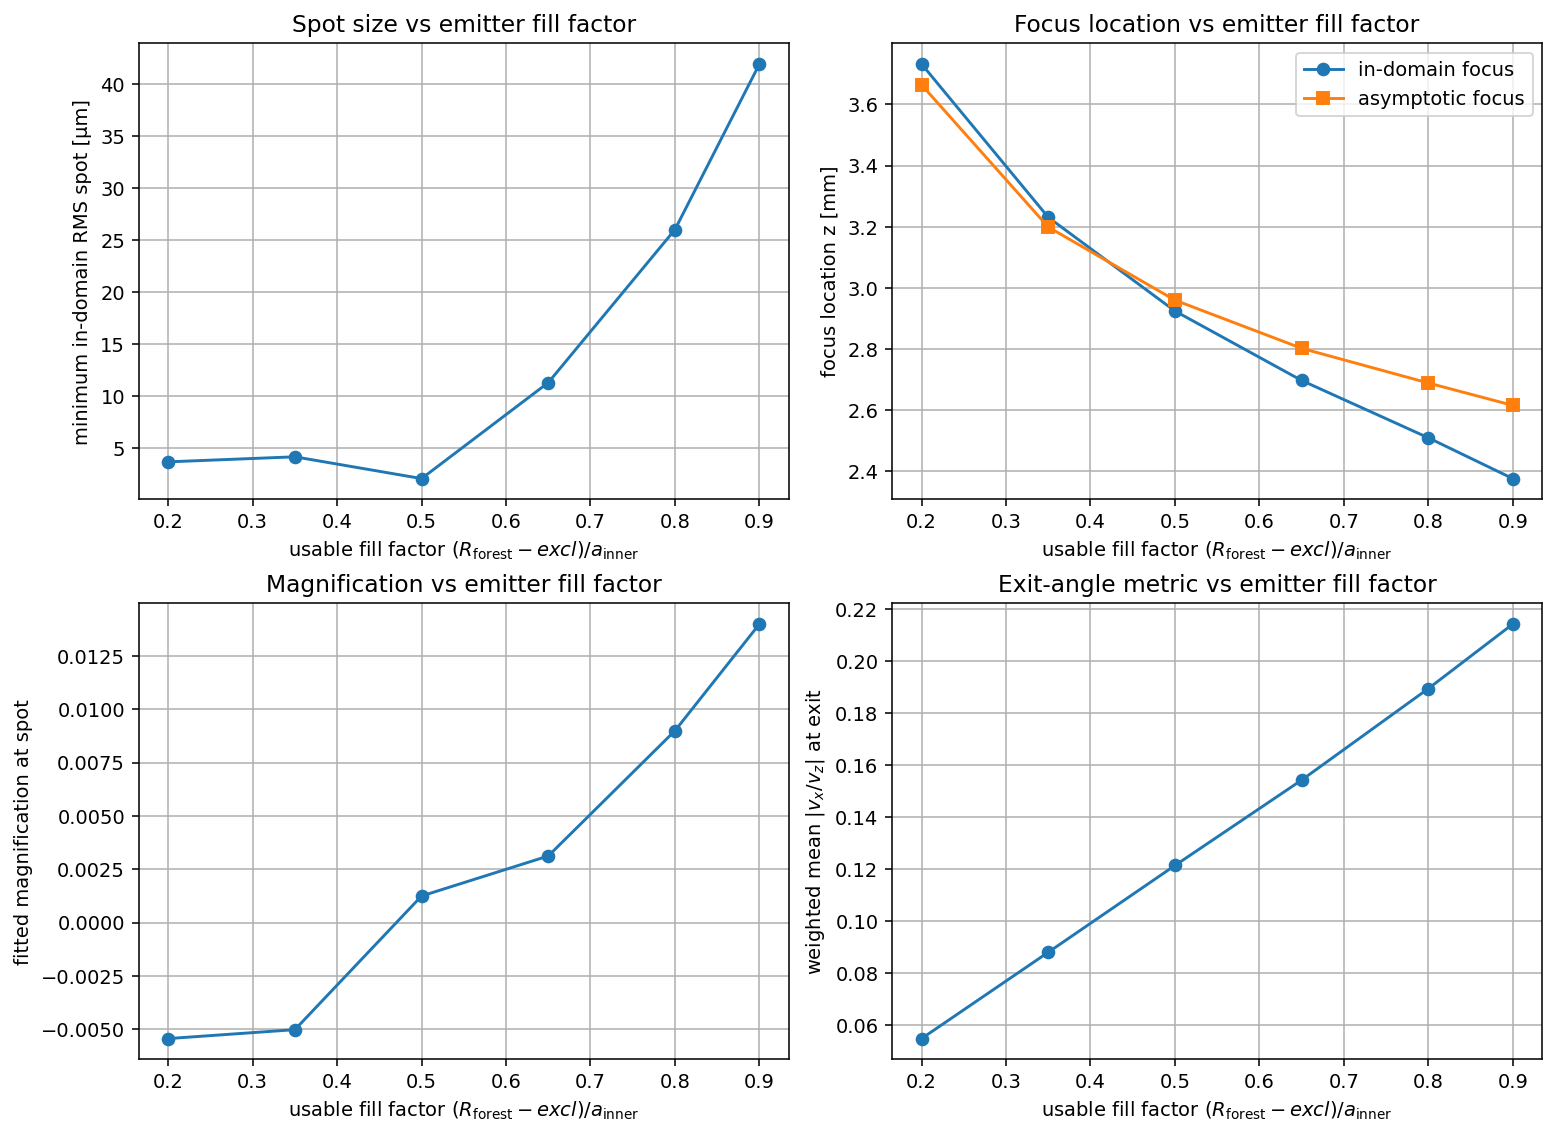

In [49]:
# Study 2: emitter fill-factor sweep at fixed 1.2 axial geometry
# Vary the usable emitting radius relative to the aperture:
# fill_factor = (R_forest - emission_edge_exclusion) / a_inner

fill_factors = np.array([0.20, 0.35, 0.50, 0.65, 0.80, 0.90], dtype=float)
axial_hold_scale = 1.20

base_params = {k: device["params"][k] for k in EXPLICIT_PARAM_KEYS}
base_domain = dict(device["domain"])
base_grid = tuple(device["grid"])

_current_launch_cfg = globals().get("launch_cfg", None)
base_n_rays = int(getattr(_current_launch_cfg, "n_rays", globals().get("n_rays", DEFAULT_N_RAYS)))
base_mode = str(getattr(_current_launch_cfg, "mode", globals().get("launch_mode", DEFAULT_LAUNCH_MODE)))
base_initial_energy_eV = float(getattr(_current_launch_cfg, "initial_energy_eV", globals().get("initial_energy_eV", DEFAULT_INITIAL_ENERGY_EV)))
base_launch_half_angle_deg = float(getattr(_current_launch_cfg, "launch_half_angle_deg", globals().get("launch_half_angle_deg", DEFAULT_HALF_ANGLE_DEG)))
base_symmetric = bool(getattr(_current_launch_cfg, "symmetric", globals().get("symmetric", True)))
base_z_offset_m = globals().get("z_offset_m", None)
base_z_offset_fraction_of_forest_height = float(globals().get("z_offset_fraction_of_forest_height", 0.20))
base_z_offset_floor_m = float(globals().get("z_offset_floor_m", 2.0e-9))

rows = []
fill_factor_runs = {}

for ff in fill_factors:
    p = dict(base_params)
    dom = dict(base_domain)

    # Hold axial geometry at 1.2x
    p["d1"] = float(base_params["d1"] * axial_hold_scale)
    p["d2"] = float(base_params["d2"] * axial_hold_scale)
    p["d3"] = float(base_params["d3"] * axial_hold_scale)
    dom["z_extra"] = float(base_domain["z_extra"] * axial_hold_scale)

    # Hold aperture fixed; vary forest size to hit the target usable fill factor
    a_inner = float(base_params["a_inner"])
    exclusion = float(base_params.get("emission_edge_exclusion", 0.0))
    usable_radius = float(ff * a_inner)
    p["R_forest"] = float(usable_radius + exclusion)

    if p["R_forest"] >= p["a_inner"]:
        rows.append({
            "fill_factor": float(ff),
            "a_inner_um": 1e6 * a_inner,
            "R_forest_um": 1e6 * p["R_forest"],
            "usable_emit_radius_um": 1e6 * usable_radius,
            "status": "invalid: R_forest >= a_inner",
        })
        continue

    scaled_device = create_lens_emitter(
        p,
        domain_overrides=dom,
        rebuild_grid=base_grid,
        allow_cached_baseline=False,
    )

    scaled_test = test_lens(
        scaled_device,
        n_rays=base_n_rays,
        mode=base_mode,
        initial_energy_eV=base_initial_energy_eV,
        launch_half_angle_deg=base_launch_half_angle_deg,
        symmetric=base_symmetric,
        z_offset_m=base_z_offset_m,
        z_offset_fraction_of_forest_height=base_z_offset_fraction_of_forest_height,
        z_offset_floor_m=base_z_offset_floor_m,
    )

    rr = scaled_test["run_result"]
    sm = rr["summary"]

    ok = rr["summary_df"][rr["summary_df"]["stop_reason"] == "top_exit"].copy()
    if len(ok) > 0:
        slopes = np.abs(ok["vx_end"].to_numpy() / ok["vz_end"].to_numpy())
        w = ok["weight"].to_numpy()
        mean_abs_exit_slope = float(np.average(slopes, weights=w))
    else:
        mean_abs_exit_slope = np.nan

    launch_radius_um = np.nan
    if "bundle_df" in rr and "x0" in rr["bundle_df"].columns:
        launch_radius_um = 1e6 * float(rr["bundle_df"]["x0"].abs().max())

    rows.append({
        "fill_factor": float(ff),
        "a_inner_um": 1e6 * a_inner,
        "R_forest_um": 1e6 * float(p["R_forest"]),
        "usable_emit_radius_um": 1e6 * usable_radius,
        "launch_radius_um": launch_radius_um,
        "spot_rms_um": 1e6 * float(sm.get("in_domain_rms_x", np.nan)),
        "focus_z_mm": 1e3 * float(sm.get("in_domain_z", np.nan)),
        "m_fit_at_spot": float(sm.get("in_domain_m_fit", np.nan)),
        "z_focus_asym_mm": 1e3 * float(sm.get("z_focus_asym", np.nan)),
        "mean_abs_exit_slope": mean_abs_exit_slope,
        "top_exit_frac": float(sm.get("n_top_exit", 0)) / max(int(sm.get("n_launch", 1)), 1),
        "status": "ok",
    })

    fill_factor_runs[float(ff)] = rr

fill_factor_df = pd.DataFrame(rows).sort_values("fill_factor").reset_index(drop=True)
display(fill_factor_df)

ok_df = fill_factor_df[fill_factor_df["status"] == "ok"].copy()

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

axes[0, 0].plot(ok_df["fill_factor"], ok_df["spot_rms_um"], marker="o")
axes[0, 0].set_xlabel(r"usable fill factor $(R_{\mathrm{forest}}-excl)/a_{\mathrm{inner}}$")
axes[0, 0].set_ylabel("minimum in-domain RMS spot [µm]")
axes[0, 0].set_title("Spot size vs emitter fill factor")

axes[0, 1].plot(ok_df["fill_factor"], ok_df["focus_z_mm"], marker="o", label="in-domain focus")
if np.isfinite(ok_df["z_focus_asym_mm"]).any():
    axes[0, 1].plot(ok_df["fill_factor"], ok_df["z_focus_asym_mm"], marker="s", label="asymptotic focus")
axes[0, 1].set_xlabel(r"usable fill factor $(R_{\mathrm{forest}}-excl)/a_{\mathrm{inner}}$")
axes[0, 1].set_ylabel("focus location z [mm]")
axes[0, 1].set_title("Focus location vs emitter fill factor")
axes[0, 1].legend()

axes[1, 0].plot(ok_df["fill_factor"], ok_df["m_fit_at_spot"], marker="o")
axes[1, 0].set_xlabel(r"usable fill factor $(R_{\mathrm{forest}}-excl)/a_{\mathrm{inner}}$")
axes[1, 0].set_ylabel("fitted magnification at spot")
axes[1, 0].set_title("Magnification vs emitter fill factor")

axes[1, 1].plot(ok_df["fill_factor"], ok_df["mean_abs_exit_slope"], marker="o")
axes[1, 1].set_xlabel(r"usable fill factor $(R_{\mathrm{forest}}-excl)/a_{\mathrm{inner}}$")
axes[1, 1].set_ylabel(r"weighted mean $|v_x/v_z|$ at exit")
axes[1, 1].set_title("Exit-angle metric vs emitter fill factor")

plt.show()

,initial_energy_eV,spot_rms_um,focus_z_mm,m_fit_at_spot,z_focus_asym_mm,mean_abs_exit_slope,top_exit_frac,max_energy_drift
0,1.000000e-02,3.957194e+00,2.848909e+00,1.092407e-03,2.904078e+00,1.328539e-01,1.000000e+00,1.205781e-06
1,5.000000e-02,3.983359e+00,2.848911e+00,9.441090e-04,2.904139e+00,1.328192e-01,1.000000e+00,1.201347e-06
2,1.000000e-01,4.003722e+00,2.848911e+00,8.431528e-04,2.904200e+00,1.327918e-01,1.000000e+00,1.039408e-06
3,2.000000e-01,4.031803e+00,2.848911e+00,7.107048e-04,2.904302e+00,1.327526e-01,1.000000e+00,1.022419e-06
4,5.000000e-01,4.093301e+00,2.848910e+00,5.175757e-04,2.904572e+00,1.326713e-01,1.000000e+00,8.083554e-07
5,1.000000e+00,4.161716e+00,2.848911e+00,3.792256e-04,2.904982e+00,1.325733e-01,1.000000e+00,1.029909e-06
6,2.000000e+00,4.263054e+00,2.848911e+00,3.637227e-04,2.905747e+00,1.324243e-01,1.000000e+00,1.106455e-06
7,5.000000e+00,4.475495e+00,2.848911e+00,9.036807e-04,2.907916e+00,1.320898e-01,1.000000e+00,1.047145e-06


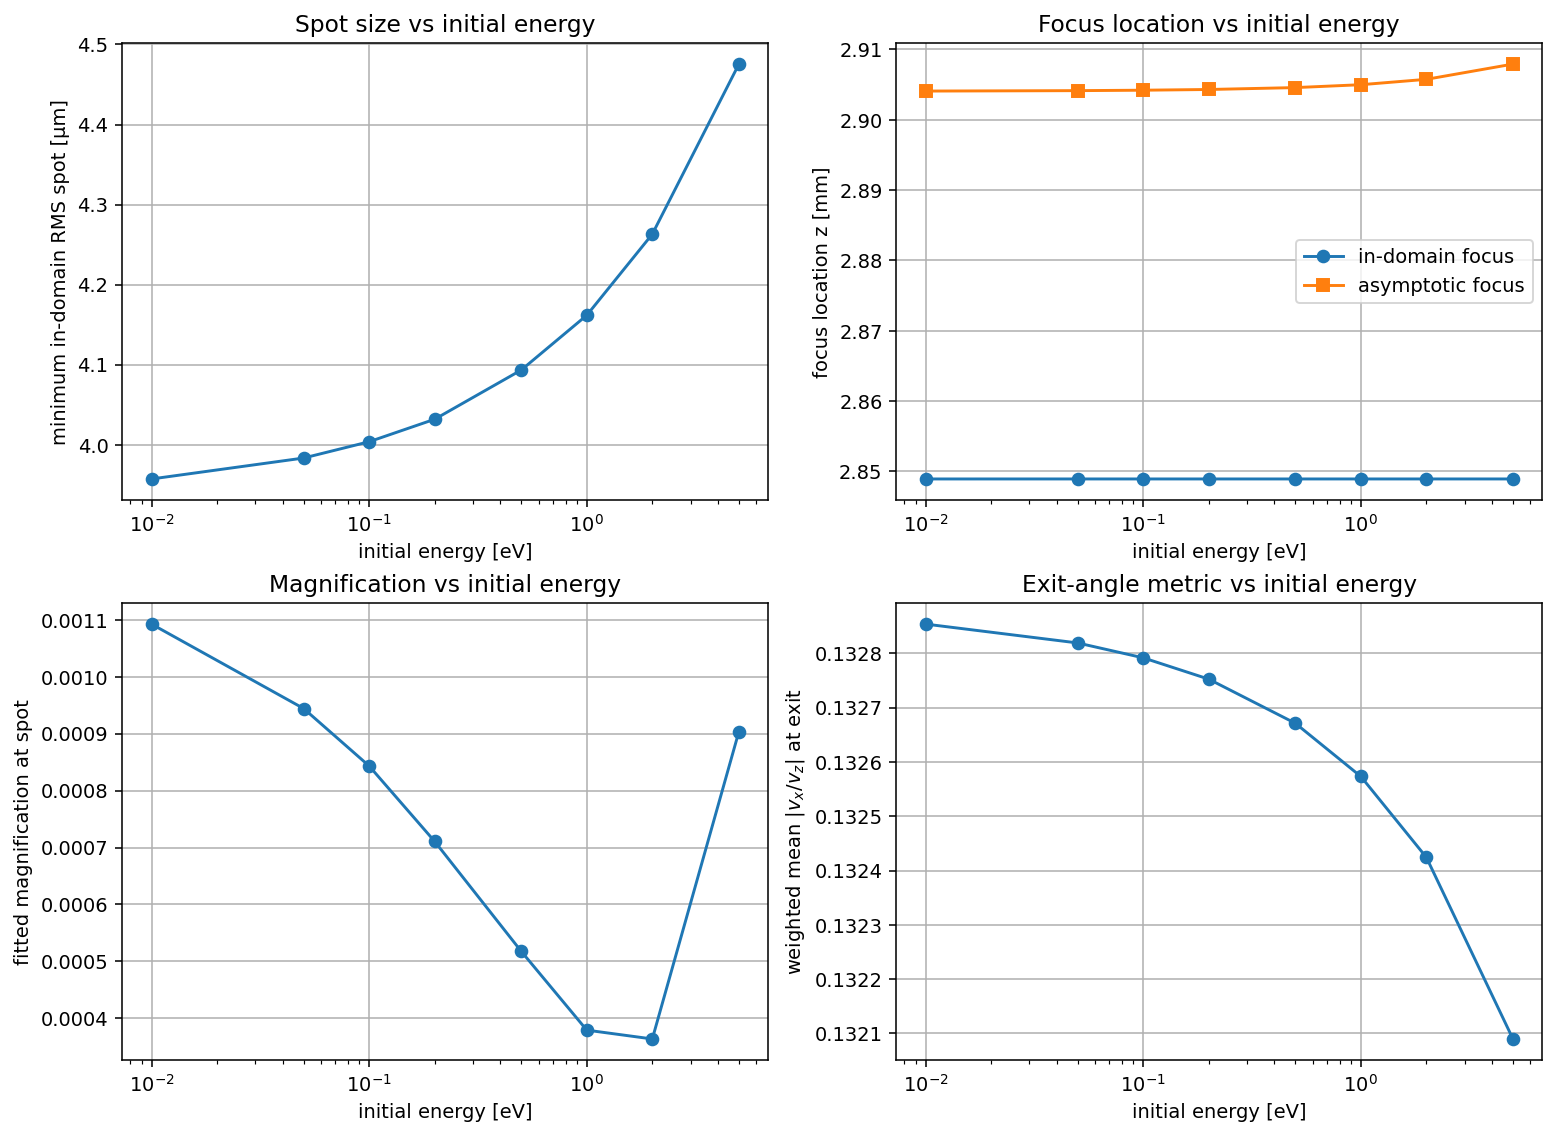

In [50]:
# Study 3: injected initial-energy sweep at fixed 1.2 axial geometry

initial_energy_values_eV = np.array([0.01, 0.05, 0.10, 0.20, 0.50, 1.00, 2.00, 5.00], dtype=float)
axial_hold_scale = 1.20

base_params = {k: device["params"][k] for k in EXPLICIT_PARAM_KEYS}
base_domain = dict(device["domain"])
base_grid = tuple(device["grid"])

_current_launch_cfg = globals().get("launch_cfg", None)
base_n_rays = int(getattr(_current_launch_cfg, "n_rays", globals().get("n_rays", DEFAULT_N_RAYS)))
base_mode = str(getattr(_current_launch_cfg, "mode", globals().get("launch_mode", DEFAULT_LAUNCH_MODE)))
base_launch_half_angle_deg = float(getattr(_current_launch_cfg, "launch_half_angle_deg", globals().get("launch_half_angle_deg", DEFAULT_HALF_ANGLE_DEG)))
base_symmetric = bool(getattr(_current_launch_cfg, "symmetric", globals().get("symmetric", True)))
base_z_offset_m = globals().get("z_offset_m", None)
base_z_offset_fraction_of_forest_height = float(globals().get("z_offset_fraction_of_forest_height", 0.20))
base_z_offset_floor_m = float(globals().get("z_offset_floor_m", 2.0e-9))

rows = []
energy_runs = {}

for E0 in initial_energy_values_eV:
    p = dict(base_params)
    dom = dict(base_domain)

    # Hold axial geometry at 1.2x
    p["d1"] = float(base_params["d1"] * axial_hold_scale)
    p["d2"] = float(base_params["d2"] * axial_hold_scale)
    p["d3"] = float(base_params["d3"] * axial_hold_scale)
    dom["z_extra"] = float(base_domain["z_extra"] * axial_hold_scale)

    scaled_device = create_lens_emitter(
        p,
        domain_overrides=dom,
        rebuild_grid=base_grid,
        allow_cached_baseline=False,
    )

    scaled_test = test_lens(
        scaled_device,
        n_rays=base_n_rays,
        mode=base_mode,
        initial_energy_eV=float(E0),
        launch_half_angle_deg=base_launch_half_angle_deg,
        symmetric=base_symmetric,
        z_offset_m=base_z_offset_m,
        z_offset_fraction_of_forest_height=base_z_offset_fraction_of_forest_height,
        z_offset_floor_m=base_z_offset_floor_m,
    )

    rr = scaled_test["run_result"]
    sm = rr["summary"]

    ok = rr["summary_df"][rr["summary_df"]["stop_reason"] == "top_exit"].copy()
    if len(ok) > 0:
        slopes = np.abs(ok["vx_end"].to_numpy() / ok["vz_end"].to_numpy())
        w = ok["weight"].to_numpy()
        mean_abs_exit_slope = float(np.average(slopes, weights=w))
    else:
        mean_abs_exit_slope = np.nan

    rows.append({
        "initial_energy_eV": float(E0),
        "spot_rms_um": 1e6 * float(sm.get("in_domain_rms_x", np.nan)),
        "focus_z_mm": 1e3 * float(sm.get("in_domain_z", np.nan)),
        "m_fit_at_spot": float(sm.get("in_domain_m_fit", np.nan)),
        "z_focus_asym_mm": 1e3 * float(sm.get("z_focus_asym", np.nan)),
        "mean_abs_exit_slope": mean_abs_exit_slope,
        "top_exit_frac": float(sm.get("n_top_exit", 0)) / max(int(sm.get("n_launch", 1)), 1),
        "max_energy_drift": float(sm.get("max_energy_drift", np.nan)),
    })

    energy_runs[float(E0)] = rr

energy_sweep_df = pd.DataFrame(rows).sort_values("initial_energy_eV").reset_index(drop=True)
display(energy_sweep_df)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

axes[0, 0].plot(energy_sweep_df["initial_energy_eV"], energy_sweep_df["spot_rms_um"], marker="o")
axes[0, 0].set_xscale("log")
axes[0, 0].set_xlabel("initial energy [eV]")
axes[0, 0].set_ylabel("minimum in-domain RMS spot [µm]")
axes[0, 0].set_title("Spot size vs initial energy")

axes[0, 1].plot(energy_sweep_df["initial_energy_eV"], energy_sweep_df["focus_z_mm"], marker="o", label="in-domain focus")
if np.isfinite(energy_sweep_df["z_focus_asym_mm"]).any():
    axes[0, 1].plot(energy_sweep_df["initial_energy_eV"], energy_sweep_df["z_focus_asym_mm"], marker="s", label="asymptotic focus")
axes[0, 1].set_xscale("log")
axes[0, 1].set_xlabel("initial energy [eV]")
axes[0, 1].set_ylabel("focus location z [mm]")
axes[0, 1].set_title("Focus location vs initial energy")
axes[0, 1].legend()

axes[1, 0].plot(energy_sweep_df["initial_energy_eV"], energy_sweep_df["m_fit_at_spot"], marker="o")
axes[1, 0].set_xscale("log")
axes[1, 0].set_xlabel("initial energy [eV]")
axes[1, 0].set_ylabel("fitted magnification at spot")
axes[1, 0].set_title("Magnification vs initial energy")

axes[1, 1].plot(energy_sweep_df["initial_energy_eV"], energy_sweep_df["mean_abs_exit_slope"], marker="o")
axes[1, 1].set_xscale("log")
axes[1, 1].set_xlabel("initial energy [eV]")
axes[1, 1].set_ylabel(r"weighted mean $|v_x/v_z|$ at exit")
axes[1, 1].set_title("Exit-angle metric vs initial energy")

plt.show()

,d1_scale_about_1p2x,d1_um,d2_um,d3_um,spot_rms_um,focus_z_mm,m_fit_at_spot,z_focus_asym_mm,mean_abs_exit_slope,top_exit_frac,max_energy_drift
0,5.000000e-01,2.100000e+02,5.400000e+02,5.400000e+02,6.281482e+01,2.995757e+00,8.981862e-02,3.423751e+00,1.809849e-01,1.000000e+00,1.034411e-06
1,7.500000e-01,3.150000e+02,5.400000e+02,5.400000e+02,1.718137e+01,3.039481e+00,1.184185e-02,3.183990e+00,1.444187e-01,1.000000e+00,1.506401e-06
2,1.000000e+00,4.200000e+02,5.400000e+02,5.400000e+02,4.031803e+00,2.848911e+00,7.107048e-04,2.904302e+00,1.327526e-01,1.000000e+00,1.022419e-06
3,1.250000e+00,5.250000e+02,5.400000e+02,5.400000e+02,3.398737e+00,2.679969e+00,-1.877124e-04,2.703807e+00,1.263123e-01,1.000000e+00,1.257572e-06
4,1.500000e+00,6.300000e+02,5.400000e+02,5.400000e+02,2.760661e+00,2.496608e+00,-2.176732e-04,2.517631e+00,1.205661e-01,1.000000e+00,9.495659e-07
5,2.000000e+00,8.400000e+02,5.400000e+02,5.400000e+02,3.305665e+00,2.504756e+00,-1.382783e-03,2.512093e+00,1.174616e-01,1.000000e+00,1.459221e-06


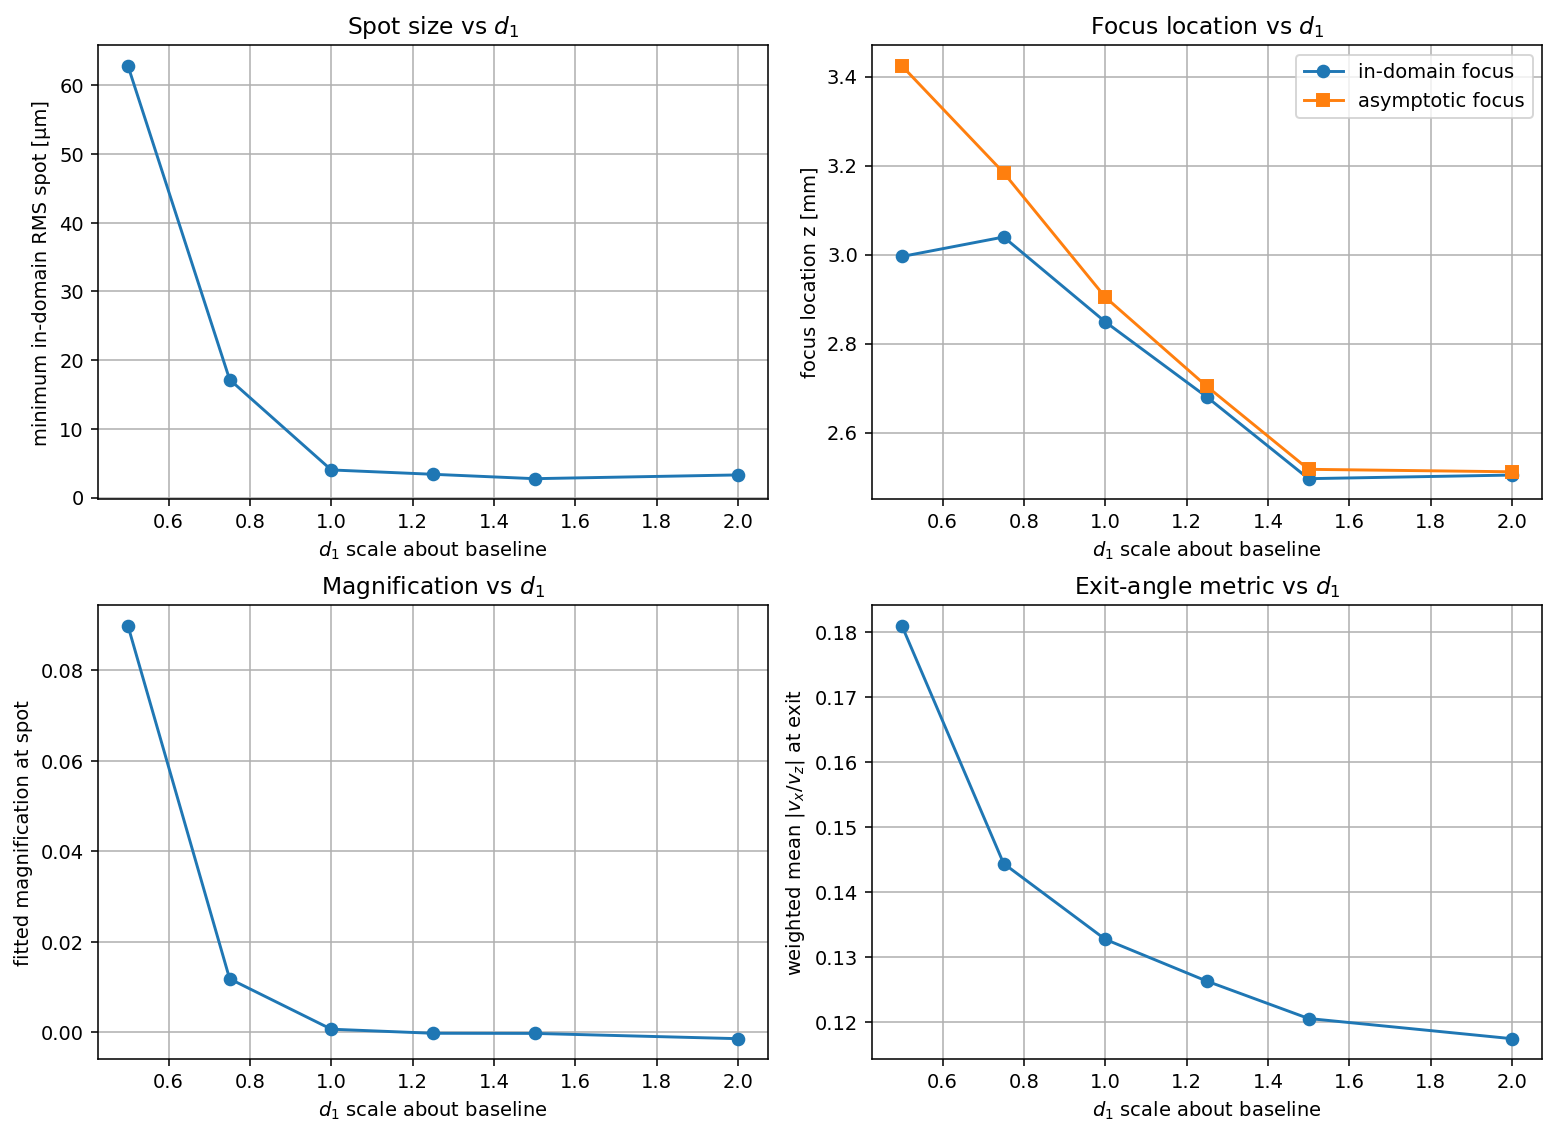

In [51]:
# Study 4: d1-only sweep around the 1.2x axial baseline
# d2, d3, and z_extra stay at the 1.2x baseline values.

d1_scale_values = np.array([0.50, 0.75, 1.00, 1.25, 1.50, 2.00], dtype=float)
axial_hold_scale = 1.20

base_params = {k: device["params"][k] for k in EXPLICIT_PARAM_KEYS}
base_domain = dict(device["domain"])
base_grid = tuple(device["grid"])

_current_launch_cfg = globals().get("launch_cfg", None)
base_n_rays = int(getattr(_current_launch_cfg, "n_rays", globals().get("n_rays", DEFAULT_N_RAYS)))
base_mode = str(getattr(_current_launch_cfg, "mode", globals().get("launch_mode", DEFAULT_LAUNCH_MODE)))
base_initial_energy_eV = float(getattr(_current_launch_cfg, "initial_energy_eV", globals().get("initial_energy_eV", DEFAULT_INITIAL_ENERGY_EV)))
base_launch_half_angle_deg = float(getattr(_current_launch_cfg, "launch_half_angle_deg", globals().get("launch_half_angle_deg", DEFAULT_HALF_ANGLE_DEG)))
base_symmetric = bool(getattr(_current_launch_cfg, "symmetric", globals().get("symmetric", True)))
base_z_offset_m = globals().get("z_offset_m", None)
base_z_offset_fraction_of_forest_height = float(globals().get("z_offset_fraction_of_forest_height", 0.20))
base_z_offset_floor_m = float(globals().get("z_offset_floor_m", 2.0e-9))

d1_baseline = float(base_params["d1"] * axial_hold_scale)

rows = []
d1_runs = {}

for s in d1_scale_values:
    p = dict(base_params)
    dom = dict(base_domain)

    # Hold most axial geometry at 1.2x
    p["d2"] = float(base_params["d2"] * axial_hold_scale)
    p["d3"] = float(base_params["d3"] * axial_hold_scale)
    dom["z_extra"] = float(base_domain["z_extra"] * axial_hold_scale)

    # Sweep only d1 around the 1.2x baseline
    p["d1"] = float(d1_baseline * s)

    scaled_device = create_lens_emitter(
        p,
        domain_overrides=dom,
        rebuild_grid=base_grid,
        allow_cached_baseline=False,
    )

    scaled_test = test_lens(
        scaled_device,
        n_rays=base_n_rays,
        mode=base_mode,
        initial_energy_eV=base_initial_energy_eV,
        launch_half_angle_deg=base_launch_half_angle_deg,
        symmetric=base_symmetric,
        z_offset_m=base_z_offset_m,
        z_offset_fraction_of_forest_height=base_z_offset_fraction_of_forest_height,
        z_offset_floor_m=base_z_offset_floor_m,
    )

    rr = scaled_test["run_result"]
    sm = rr["summary"]

    ok = rr["summary_df"][rr["summary_df"]["stop_reason"] == "top_exit"].copy()
    if len(ok) > 0:
        slopes = np.abs(ok["vx_end"].to_numpy() / ok["vz_end"].to_numpy())
        w = ok["weight"].to_numpy()
        mean_abs_exit_slope = float(np.average(slopes, weights=w))
    else:
        mean_abs_exit_slope = np.nan

    rows.append({
        "d1_scale_about_1p2x": float(s),
        "d1_um": 1e6 * float(p["d1"]),
        "d2_um": 1e6 * float(p["d2"]),
        "d3_um": 1e6 * float(p["d3"]),
        "spot_rms_um": 1e6 * float(sm.get("in_domain_rms_x", np.nan)),
        "focus_z_mm": 1e3 * float(sm.get("in_domain_z", np.nan)),
        "m_fit_at_spot": float(sm.get("in_domain_m_fit", np.nan)),
        "z_focus_asym_mm": 1e3 * float(sm.get("z_focus_asym", np.nan)),
        "mean_abs_exit_slope": mean_abs_exit_slope,
        "top_exit_frac": float(sm.get("n_top_exit", 0)) / max(int(sm.get("n_launch", 1)), 1),
        "max_energy_drift": float(sm.get("max_energy_drift", np.nan)),
    })

    d1_runs[float(s)] = rr

d1_sweep_df = pd.DataFrame(rows).sort_values("d1_scale_about_1p2x").reset_index(drop=True)
display(d1_sweep_df)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

axes[0, 0].plot(d1_sweep_df["d1_scale_about_1p2x"], d1_sweep_df["spot_rms_um"], marker="o")
axes[0, 0].set_xlabel(r"$d_1$ scale about baseline")
axes[0, 0].set_ylabel("minimum in-domain RMS spot [µm]")
axes[0, 0].set_title(r"Spot size vs $d_1$")

axes[0, 1].plot(d1_sweep_df["d1_scale_about_1p2x"], d1_sweep_df["focus_z_mm"], marker="o", label="in-domain focus")
if np.isfinite(d1_sweep_df["z_focus_asym_mm"]).any():
    axes[0, 1].plot(d1_sweep_df["d1_scale_about_1p2x"], d1_sweep_df["z_focus_asym_mm"], marker="s", label="asymptotic focus")
axes[0, 1].set_xlabel(r"$d_1$ scale about baseline")
axes[0, 1].set_ylabel("focus location z [mm]")
axes[0, 1].set_title(r"Focus location vs $d_1$")
axes[0, 1].legend()

axes[1, 0].plot(d1_sweep_df["d1_scale_about_1p2x"], d1_sweep_df["m_fit_at_spot"], marker="o")
axes[1, 0].set_xlabel(r"$d_1$ scale about baseline")
axes[1, 0].set_ylabel("fitted magnification at spot")
axes[1, 0].set_title(r"Magnification vs $d_1$")

axes[1, 1].plot(d1_sweep_df["d1_scale_about_1p2x"], d1_sweep_df["mean_abs_exit_slope"], marker="o")
axes[1, 1].set_xlabel(r"$d_1$ scale about baseline")
axes[1, 1].set_ylabel(r"weighted mean $|v_x/v_z|$ at exit")
axes[1, 1].set_title(r"Exit-angle metric vs $d_1$")

plt.show()

## 9. Notes for manual studies

- To change the **device physics**, edit **Step 1** and rerun the build cell.
- To keep the same device but change only the **trajectory test**, edit **Step 2** and rerun only the test cells.
- The active launch radius is always:

  \[
  r_{\max,\mathrm{launch}} = R_{\mathrm{forest}} - \texttt{emission\_edge\_exclusion}.
  \]

That makes it easy to verify whether the launched bundle is actually compatible with the emitter you specified.